In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit

import copy

import sys
# ESA pc
sys.path.append('/home/rkievit/masterproject/masterproject/src') 
# Home PC
sys.path.append('F:\\OneDrive - Telecom Business Transformers BV\\School\\Uni\\MSc Year 2\\Master Research Project\\Project\\masterproject\\src')
# Uni PC
sys.path.append('/net/student36/data2/kievit/Master Project/masterproject/src')

from data_queries import query_extra_data, gaia_login, launch_job, get_data
from astrometry_equations import angular_distance, compute_error_normalized_distance

In [3]:
def rayleigh(x, sigma):
    return (x/(sigma**2)) * np.exp(-0.5*((x/sigma)**2.))

In [4]:
radius = '1as'
method = 'nearest'
extension = ''

rpath = '../../results/'
fpath = '../../../figures/'
dpath = '../../../data/' 
#xm_all = np.load(rpath+f'crossmatch{extension}_{radius}_all_neighbours.npy')
#xm_near = np.load(rpath+f'crossmatch{extension}_{radius}_best_neighbour_nearest.npy')
#xm_bright = np.load(rpath+f'crossmatch{extension}_{radius}_best_neighbour_brightest.npy')

#xm = np.load(rpath+f'crossmatch{extension}_{radius}_best_neighbour_{method}.npy')
#xm_marrese =

In [6]:
# Get Gaia data
extra_gdata = ['phot_g_mean_mag', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error']
xm_all, gdata_all = query_extra_data(xm_all, extra_gdata)
xm_near, gdata_near = query_extra_data(xm_near, extra_gdata)
xm_bright, gdata_bright = query_extra_data(xm_bright, extra_gdata)

# Get Hipp data
extra_hdata = ['hp_mag', 'b_v']
xm_all, hdata_all = query_extra_data(xm_all, extra_hdata, cat='hipp')
xm_near, hdata_near = query_extra_data(xm_near, extra_hdata, cat='hipp')
xm_bright, hdata_bright = query_extra_data(xm_bright, extra_hdata, cat='hipp')

NameError: name 'xm_all' is not defined

## Hipparcos Values Matched vs. Unmatched

In [ ]:
hipp = fits.open(dpath+'Hipparcos2.fits')[1].data
hip_ids = hipp['hip']

hip_matched = [] # Appending slow but whatever
hip_nomatch = []

for i,hip in enumerate(hip_ids):
    if hip in xm[:,0]:
        hip_matched.append(i)
    else:
        hip_nomatch.append(i)
hip_matched = np.array(hip_matched)
hip_nomatch = np.array(hip_nomatch)

In [ ]:
print(f"Number of matched Hipparcos stars: {hip_matched.shape[0]}")
print(f"Number of unmatched Hipparcos stars: {hip_nomatch.shape[0]}")

In [ ]:
# Compare histograms of magnitude
fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(hipp['hp_mag'][hip_matched], histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(hipp['hp_mag'][hip_nomatch], histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Hp Magnitude')
ax.set_ylabel('log Counts')
ax.set_title(f"Hp Histogram (r={radius}, method={method})")
ax.invert_xaxis()

plt.legend()
plt.show()

In [ ]:
# Compare histogram of proper mitions
pm_matched = np.sqrt((hipp['pm_ra'][hip_matched]**2.) + (hipp['pm_de'][hip_matched]**2))
pm_nomatch = np.sqrt((hipp['pm_ra'][hip_nomatch]**2.) + (hipp['pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(pm_matched), histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Total Proper Motion (milli-arcsecond / year)')
ax.set_ylabel('log Counts')
ax.set_title(f"Log Total Proper Motion Histogram")


plt.legend()
plt.show()

In [ ]:
# Compare histogram of proper motion errors
e_pm_matched = np.sqrt((hipp['e_pm_ra'][hip_matched]**2.) + (hipp['e_pm_de'][hip_matched]**2))
e_pm_nomatch = np.sqrt((hipp['e_pm_ra'][hip_nomatch]**2.) + (hipp['e_pm_de'][hip_nomatch]**2))

fig, ax = plt.subplots(1,1, figsize=(8,4))

ax.hist(np.log10(e_pm_matched),histtype='step', lw=3, log=True, label='Cross-Matched')
ax.hist(np.log10(e_pm_nomatch), histtype='step', lw=3, log=True, label='Not Matched')
ax.set_xlabel('Log Total Proper Motion Error (milli-arcsecond / year)')

ax.set_ylabel('log Counts')
ax.set_title(f"Proper motion error Histogram (r={radius}, method={method})")

plt.legend()
plt.show()

## Gaia properties of Matched objects

In [ ]:
match_method = 'nearest'
print(extra_gdata)
print(extra_hdata)
hipp_bv = hdata_near[:,1]
hp_mag = hdata_near[:,0]
gaia_g = gdata_near[:,0]

In [ ]:
# G - Hp relation reported on the gaia archive doccs
x = np.linspace(np.min(hipp_bv), np.max(hipp_bv), 1000)
y = -0.02392 - 0.4069*x + 0.04569*(x**2) - 0.0452*(x**3)
sigma = 0.02417

fig, ax = plt.subplots(1,1, figsize=(8, 6))
bv0_mask = np.where(hipp_bv==0.)

scatter = ax.scatter(hipp_bv, gaia_g-hp_mag, s=2, c=gaia_g)
ax.scatter(hipp_bv[bv0_mask], (gaia_g-hp_mag)[bv0_mask], s=2, c='red', label='B-V = 0')
ax.plot(x,y,c='black',ls='--', label=f"H$_p$ - G relation")
ax.fill_between(x,y-sigma,y+sigma, color='gray', label=f'$1\sigma$')
cb = plt.colorbar(scatter)
cb.set_label(f"H$_p$  Magnitude")

ax.set_ylabel(f"H$_p$ - G")
ax.set_xlabel("Hipparcos B-V")
ax.set_title(f"Gaia - Hipparcos Magnitude Relation ({match_method})")

plt.legend()

plt.savefig(fpath+'gaiapred_bvcol.png', bbox_inches='tight')
plt.show()

The white line is the assumption we have made for the limit of the magnitude of Gaia objects, this line should perfectly match with the observations if this relation exactly holds. If an object lies above this black line, then Hp - G is bigger, and thus the Gaia star is brighter. If the star is below the line, then the Gaia star is less bright then we had assumed

In [ ]:
# Difference between G_pred and matched G
x = hipp_bv
G_pred = -0.02392 - 0.4069*x + 0.04569*(x**2) - 0.0452*(x**3) + hp_mag
best_line = np.arange(min(gaia_g), max(gaia_g))

fig, ax = plt.subplots(1,1, figsize=(8,6))

scatter = ax.scatter(gaia_g, G_pred, s=2, c=hipp_bv)
cb = plt.colorbar(scatter)
cb.set_label("Hipparcos B-V")
ax.plot(best_line, best_line, c='black', label="Perfect Prediction")

ax.set_xlabel("G")
ax.set_ylabel("G$_{pred}$")
ax.set_title(f"Predicted G vs. Matched G ({match_method})")
ax.invert_xaxis()
ax.invert_yaxis()


plt.legend()
plt.savefig(fpath+'gaiapred_gaiamatch.png', bbox_inches='tight')
plt.show()

In [ ]:
pos_gaia_params_full = ['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'ra_dec_prop', 'ra', 'dec', 'pmra', 'pmdec']
pos_gaia_params = ['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'ra_dec_prop']
pos_hipp_params = ['ra', 'dec', 'e_ra_rad', 'e_de_rad', 'u2']
xm = xm_all

#xm, pos_gaia = query_extra_data(xm, pos_gaia_params, cat='GaiaBaseCat', cat_dpath='../../../data/')
# Difficult to query Gaia data because the cat file is too big.

_, pos_hipp_table = query_extra_data(xm, pos_hipp_params, cat='hipp')
print(extension)
cat_gaia = fits.open(f'../../../data/GaiaBaseCat{extension}.fits')[1].data
# This for loop populates the pos_gaia table following GaiaCat_ID in the xm tables.
pos_gaia_table = np.zeros((xm.shape[0], len(pos_gaia_params)))
#pos_gaia_table_full = np.zeros((xm.shape[0], len(pos_gaia_params_full)))
for i, label in enumerate(pos_gaia_params):
    pos_gaia_table[:, i] = cat_gaia[label][xm[:,2]]

#for i, label in enumerate(pos_gaia_params_full):
    #pos_gaia_table_full[:, i] = cat_gaia[label][xm[:,2]]

pos_gaia_table_full = copy.deepcopy(cat_gaia)
pos_gaia_table_full = pos_gaia_table_full[xm[:,2]]

In [ ]:
# Manual cross match on a Gaia Cat. This is incredibly slow. Should be able to do this better.
# For nearest implementation. Do it only for those objects where it is necessary
# The below code is for a full run.
pos_gaia = np.zeros((xm.shape[0], len(pos_gaia_params)))
for i,gaia_id in enumerate(xm[:,1]):
    cat_idx = np.where(cat_gaia['source_id'] == gaia_id)
    for j, label in enumerate(pos_gaia_params):
        pos_gaia[i][j] = cat_gaia[cat_idx][label]
    print(f'{i}/{xm.shape[0]}', end='\r')

## Plotting of sky regions around Hipparcos object

In [ ]:
# The indexing here is absolutely terrible. But it works
# Plot double candidate stars
u, idx, c = np.unique(xm[:, 0], return_counts=True, return_index=True)
doubles = idx[c>1]

random_choice = np.random.choice(doubles)
#random_choice = np.random.choice(idx)
random_idx = np.where(idx == random_choice)[0][0] # assumes it only occurs once. Which it must because np.unique

hipp_id = u[random_idx]
pos_hipp = pos_hipp_table[idx[random_idx]]
print(c[random_idx])
gaia_ids = xm[idx[random_idx]:idx[random_idx]+c[random_idx]][:,1]
#pos_gaia = pos_gaia_table[idx[random_idx]: idx[random_idx] + c[random_idx]]
pos_gaia = pos_gaia_table_full[idx[random_idx]: idx[random_idx] + c[random_idx]]



#gaia_ids = []
#pos_gaia = np.zeros((c[random_idx], len(pos_gaia_params)+1))
#
#for i in range(c[random_idx]):
#    gaia_cat_idx = np.where(cat_gaia['source_id'] == xm[idx[random_idx]+i][1])
#
#    for j, label in enumerate(pos_gaia_params):
#        pos_gaia[i][j] = cat_gaia[gaia_cat_idx][label]
#    pos_gaia[i][-1] = xm[random_idx+i][1]

In [ ]:
gaia_ids

In [ ]:
# Plot star + error bars for randomly chosen object
ei = 1 # error inflation for testing

u, idx, c = np.unique(xm[:, 0], return_counts=True, return_index=True)
doubles = idx[c>1]

random_choice = np.random.choice(doubles)
#random_choice = np.random.choice(idx)
random_idx = np.where(idx == random_choice)[0][0] # assumes it only occurs once. Which it must because np.unique

hipp_id = u[random_idx]
pos_hipp = pos_hipp_table[idx[random_idx]]

gaia_ids = xm[idx[random_idx]:idx[random_idx]+c[random_idx]][:,1]
pos_gaia = pos_gaia_table[idx[random_idx]: idx[random_idx] + c[random_idx]]

from matplotlib.patches import Circle, Ellipse
print(xm[idx[random_idx]])

cs_radius = 1
fig, ax = plt.subplots(1,1, figsize=(6,6))

ra_h = pos_hipp[0] * 3600 * 1e3
de_h = pos_hipp[1] * 3600 * 1e3

ax.scatter(0, 0, s=100, c='yellow', marker='*',label='Hipparcos')
hipp_err_ellipse = Ellipse((0,0), ei*pos_hipp[2], ei*pos_hipp[3], fill=False, ec='yellow')
ax.add_patch(hipp_err_ellipse)


conesearch_circle = Circle((0,0), cs_radius * 1e3, fill=False, ec='black', ls='--', label=f'{cs_radius}" as')
ax.add_patch(conesearch_circle)

for i,pos in enumerate(pos_gaia):
    print(gaia_ids[i])
    ra = pos[0] * 3600 * 1e3
    de = pos[1] * 3600 * 1e3
    ax.scatter(ra - ra_h, de - de_h,  label=np.int64(gaia_ids[i]), c=f'C{i}')
    gaia_err_ellipse = Ellipse((ra - ra_h, de - de_h), ei*pos[2], ei*pos[3], fill=False, color=f'C{i}')

    ax.add_patch(gaia_err_ellipse)

ax.set_xlabel(r"$\Delta\alpha$ [mas]")
ax.set_ylabel(r"$\Delta\delta$ [mas]")
ax.set_title(f"Hipparcos Star {hipp_id} at ({pos_hipp[0]:.2f}, {pos_hipp[1]:.2f}) degrees")

#plt.savefig('../../../figures/example_skyplot_sigma.png', bbox_inches='tight')

#sq_scale = 5 # mas
#ax.set_xlim(-sq_scale, +sq_scale)
#ax.set_ylim(-sq_scale, +sq_scale)

#plt.savefig('../../../figures/example_skyplot_sigma_zoomed.png', bbox_inches='tight')

plt.legend()
plt.show()


ra_h = np.radians(pos_hipp[0])
de_h = np.radians(pos_hipp[1])
ra_g = np.radians(pos_gaia[0][0])
de_g = np.radians(pos_gaia[0][1])

factor1 = (ra_h - ra_g) * np.cos(np.radians(de_h))
factor2 = de_h - de_g
distance = np.sqrt((factor1 ** 2) + (factor2 ** 2))
distance_mas = 3600 * 1e3 * np.degrees(distance)

avg_hipp_error = (1./np.sqrt(2)) * np.sqrt(pos_hipp[2]**2 + pos_hipp[3]**2)
error_w_distance = distance_mas/avg_hipp_error # avg_hipp_error is supposed to be in mas

print(f"Distance between Gaia and Hipparcos object is {distance_mas:.2f} mas")
print(f"This corresponds to {error_w_distance} sigma_hipparcos.")

#dist = angular_distance2(pos_hipp[0], pos_hipp[1], pos_gaia[0][0], pos_gaia[0][1], unit='degrees')


In [ ]:
# Plot for presentation of Gaia propagation
ei = 1 # error inflation for testing

cs_radius = 1
fig, axs = plt.subplots(1,2, figsize=(12,6))

ra_h = pos_hipp[0] * 3600 * 1e3
de_h = pos_hipp[1] * 3600 * 1e3
avg_hipp_er = np.sqrt((pos_hipp[2])**2 + (pos_hipp[3])**2)

# Left Square
axs[0].scatter(0, 0, c='black',label='Hipparcos', zorder=3)
hipp_err_ellipse = Ellipse((0,0), ei*pos_hipp[2], ei*pos_hipp[3], fill=False, ec='yellow')
axs[0].add_patch(hipp_err_ellipse)


conesearch_circle = Circle((0,0), cs_radius * 1e3, fill=False, ec='black', ls='--', label=f'{cs_radius}" as')
axs[0].add_patch(conesearch_circle)


for i,pos in enumerate(pos_gaia_table_full[idx[random_idx] : idx[random_idx] + c[random_idx]]):
    ra = pos['ra_prop'] * 3600 * 1e3
    de = pos['dec_prop'] * 3600 * 1e3
    axs[0].scatter(ra - ra_h, de - de_h,  label=f'{i+1} (J1991.25)', c=f'C{i}')
    gaia_err_ellipse = Ellipse((ra - ra_h, de - de_h), ei*pos['e_ra_prop'], ei*pos['e_de_prop'], 
                               fill=False, color=f'C{i}')
    axs[0].add_patch(gaia_err_ellipse)
      
    ra = pos['ra'] * 3600 * 1e3
    de = pos['dec'] * 3600 * 1e3
    axs[0].scatter(ra - ra_h, de - de_h, label=f'{i+1} (J2016.0)', c=f'C{i+2}')
    
    #axs[0].arrow(ra-ra_h, de-de_h, pos['pmra'], pos['pmdec'], color=f'C{i+2}', head_width=50)
    print(pos['e_ra_prop'])

#sq_scale = 1000 # mas
#axs[0].set_xlim(-sq_scale, +sq_scale)
#axs[0].set_ylim(-sq_scale, +sq_scale)

# Right square
axs[1].scatter(0, 0, c='black')#,label='Hipparcos')
hipp_err_ellipse = Ellipse((0,0), ei*pos_hipp[2], ei*pos_hipp[3], fill=False, ec='black')
axs[1].add_patch(hipp_err_ellipse)


conesearch_circle = Circle((0,0), cs_radius * 1e3, fill=False, ec='black', ls='--')#, label=f'{cs_radius}" as')
axs[1].add_patch(conesearch_circle)

for i,pos in enumerate(pos_gaia_table_full[idx[random_idx] : idx[random_idx] + c[random_idx] ]):

    ra = pos['ra_prop'] * 3600 * 1e3
    de = pos['dec_prop'] * 3600 * 1e3
    axs[1].scatter(ra - ra_h, de - de_h, c=f'C{i}')
    gaia_err_ellipse = Ellipse((ra - ra_h, de - de_h), ei*pos['e_ra_prop'], ei*pos['e_de_prop'], 
                           fill=False, color=f'C{i}')
    axs[1].add_patch(gaia_err_ellipse)
    
    avg_gaia_error = (1./np.sqrt(2)) * np.sqrt((pos['e_ra_prop']**2) + (pos['e_de_prop']**2))
    avg_error = (1./np.sqrt(2)) * np.sqrt((avg_gaia_error**2) + (avg_hipp_er)**2)

    distance = np.sqrt((ra-ra_h)**2 + (de-de_h)**2)
    ew_distance = distance/avg_error

    axs[1].plot([0,ra-ra_h],[0,de-de_h], c='black', ls='--', label=f'{ew_distance:.2f}'+r'$\sigma_{avg}$')
    print(pos['pmra_prop'], pos['pmdec_prop'])

#plt.savefig('../../../figures/example_skyplot_sigma.png', bbox_inches='tight')

sq_scale = 800 # mas
axs[1].set_xlim(-sq_scale, +sq_scale)
axs[1].set_ylim(-sq_scale, +sq_scale)

#plt.savefig('../../../figures/example_skyplot_sigma_zoomed.png', bbox_inches='tight')

for ax in axs:
    ax.set_xlabel(r"$\Delta\alpha$ [mas]")
    ax.set_ylabel(r"$\Delta\delta$ [mas]")
    ax.legend()
plt.suptitle(f"Hipparcos Star {hipp_id} at ({pos_hipp[0]:.2f}, {pos_hipp[1]:.2f}) degrees")
plt.savefig(fpath+'example_skypiece', bbox_inches='tight', transparent=True)
plt.show()



#dist = angular_distance2(pos_hipp[0], pos_hipp[1], pos_gaia[0][0], pos_gaia[0][1], unit='degrees')

#### List all of the properties of the two matched objects above. For the extra data querying, the above is of course done from '_all'

In [ ]:
from astrometry_equations import predict_G_bv
fits.open(f'../../../data/GaiaBaseCat{extension}.fits')[1].data

In [ ]:
gaia_data = pos_gaia_table_full[idx[random_idx] : idx[random_idx] + c[random_idx] ]
hipp_data = pos_hipp_table[idx[random_idx]]
hipp_extra = hdata_all[idx[random_idx]]
print(extra_hdata)
print(hipp_data, hipp_extra)
print(gaia_data)
print(gaia_data[0]['pmra'])

In [ ]:
# Overview

ra_h = pos_hipp[0] * 3600 * 1e3
de_h = pos_hipp[1] * 3600 * 1e3
avg_hipp_er = np.sqrt((pos_hipp[2])**2 + (pos_hipp[3])**2)

print(f"""Hipparcos Object:
Hipparcos Magnitude: {hipp_extra[0]}
B-V Colour:          {hipp_extra[1]}
Predicted Gaia Mag.: {predict_G_bv(hipp_extra[0], hipp_extra[1]):.2f}""")

print('---------------------------')


for i in range(gaia_data.shape[0]):
    pos = gaia_data[i]

    ra = pos['ra_prop'] * 3600 * 1e3
    de = pos['dec_prop'] * 3600 * 1e3
    era, ede = pos['e_ra_prop'], pos['e_de_prop']

    avg_gaia_error = np.sqrt((era**2) + (ede**2))
    avg_error = np.sqrt((avg_gaia_error**2) + (avg_hipp_er)**2)

    distance = np.sqrt((ra-ra_h)**2 + (de-de_h)**2)
    ew_distance = distance/avg_error

    print(f"""Gaia Match {i+1}:
    Avg. Sigma Distance: {ew_distance:.1f} sigma
    Gaia Magnitude:      {pos['phot_g_mean_mag']:.2f}
    Bp - Rp colour:      {pos['bp_rp']:.2f}""")

## Investigate distances between matches from full crossmatch

In [5]:
def gaussian(x, mu, sigma, amp):
    return amp/(sigma * 2 * np.pi) * np.exp(-0.5*((x-mu)**2.)/sigma**2)

from scipy.optimize import curve_fit

In [ ]:
print(pos_hipp_params)
print(pos_gaia_params)
print(pos_gaia_table.shape)
print(xm.shape)

In [ ]:

distances = angular_distance(pos_hipp_table[:,0], pos_hipp_table[:,1], pos_gaia_table[:,0], pos_gaia_table[:,1], unit='degrees')
distances_mas = np.degrees(distances) * 3600 * 1e3
avg_hipp_errors = (1./np.sqrt(2)) * np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
avg_gaia_errors = (1./np.sqrt(2)) * np.sqrt((pos_gaia_table[:, 2])**2 + (pos_gaia_table[: ,3])**2)
avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
error_w_distances = distances_mas / avg_errors

In [ ]:
print(f"Average Hipparcos Uncertainty is {np.mean(avg_hipp_errors):.2f} mas")
print(f"Average Gaia Uncertainty is      {np.mean(avg_gaia_errors):.2f} mas")

In [ ]:
#from astroquery.gaia import Gaia
from data_queries import gaia_login, launch_job, get_data
job = 'select ra_error, dec_error from gaiadr3.gaia_source where phot_g_mean_mag < 14'
gaia_login()
query = launch_job(job)
gaia_uncertainties = get_data(query)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(gaia_uncertainties['ra_error']), log=True, density=True, bins=50, histtype='step', label=r'$\sigma_{gaia}$ J2016.0')
ax.hist(np.log10(avg_gaia_errors), log=True, bins=50, density=True, histtype='step', label=r'$\sigma_{gaia}$ J1991.25')
ax.hist(np.log10(avg_hipp_errors), log=True, bins=50, density=True, histtype='step', label=r'$\sigma_{hipp}$')

ax.set_xlabel('Log Average Uncertainty [mas]')
ax.set_ylabel('Normalized Density')
ax.set_title('Positional Uncertainty Comparison')

ax.legend(loc='upper right')
plt.show()

In [ ]:
# Distances Histogram
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.hist(np.log10(distances_mas), log=True, histtype='step')

ax.set_xlabel("Log Angular Separation [mas]")
ax.set_ylabel("Log Counts")
ax.set_title("Distance between matches")

plt.savefig(fpath+f"xm{extension}_{radius}_nearest_angsep.png", bbox_inches='tight')
plt.show()


In [ ]:


# EW Distances Histogram
fig, ax = plt.subplots(1,1, figsize=(8,6))
n, bins, patch = ax.hist(np.log(error_w_distances), bins=100, log=True, histtype='step', density=True)
#print(n, bins)

#ax.hist(error_w_distances)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

x = np.logspace(-3, +3)
#x.plot(np.log(x), gaussian(x, 0, 1, 1))
ax.plot(np.log(x), rayleigh(x, 1))
#popt, pcov = curve_fit(gaussian, bins, n, p0=[1,1,1])


ax.set_xlabel("Log Angular Separation in average uncertainty")
ax.set_ylabel("Log Counts")
ax.set_title("Error weighted distance between matches")

ax.set_xlim(xlim)
ax.set_ylim(ylim)

#plt.savefig(fpath+f"xm{extension}_{radius}_nearest_angsep.png", bbox_inches='tight')
plt.show()


In [ ]:
plt.hist(np.log10(avg_gaia_errors), log=True, bins=50)

In [ ]:
# !TAKE CARE WHEN RUNNING THIS BECAUSE IT WILL MESS WITH THE ABOVE CODE!
extension_types = ['', '+PMC', '+EIB', '+PMC+EIB']
radius = '1as'
method = 'nearest'
radius_ar = ['1as', '2as', '3as', '5as', '10as']

fig, axs = plt.subplots(5,2, figsize=(14,30), sharey=True, sharex=True, tight_layout=True)

# Labelling
axs[4][0].set_xlabel('Log Angular Separation [mas]')
axs[4][1].set_xlabel(r'Log Angular Separation [$\sigma_{avg}$]')

axs[0][0].set_title('Angular Distance')
axs[0][1].set_title('Error Weighted Distance')
plt.suptitle('Hipparcos - Gaia crossmatch separation')



for i, radius in enumerate(radius_ar):
    axs[i][0].set_ylabel('Log Counts')

    for ext in extension_types:
        # Import XM data. xm looks like: [[hip1, source_id1, gaia_cat_id1], [..], ..., [..]]
        xm = np.load(rpath+f'crossmatch{ext}_{radius}_best_neighbour_{method}.npy')

        #Hipp data
        _, pos_hipp_table = query_extra_data(xm, pos_hipp_params, cat='hipp')

        # Create Gaia data table
        cat_gaia = fits.open(f'../../../data/GaiaBaseCat{ext}.fits')[1].data

        # This for loop populates the pos_gaia table following GaiaCat_ID in the xm tables.
        pos_gaia_table = np.zeros((xm.shape[0], len(pos_gaia_params)))
        for j, label in enumerate(pos_gaia_params):
            pos_gaia_table[:, j] = cat_gaia[label][xm[:,2]]

        # Compute distances + Errors
        pos_hipp_table = pos_hipp_table.astype(float)
        pos_gaia_table = pos_gaia_table.astype(float)

        # Annoying work around below. Some error with wrong data types when doing np.radians on everything at the same time.
        # Below code seems to work properly though
        ra_a = np.radians(pos_hipp_table[:,0])
        dec_a = np.radians(pos_hipp_table[:,1])
        ra_b = np.radians(pos_gaia_table[:,0])
        dec_b = np.radians(pos_gaia_table[:,1])
        distances = angular_distance(ra_a, dec_a, ra_b, dec_b)

        distances_mas = np.degrees(distances) * 3600 * 1e3
        avg_hipp_errors = np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
        avg_gaia_errors = np.sqrt((pos_gaia_table[:, 2])**1 + (pos_gaia_table[: ,3])**2)
        avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
        error_w_distances = distances_mas / avg_errors

        # Plotting
        axs[i][0].hist(np.log10(distances_mas), log=True, histtype='step', label=ext)#, bins=20)
        axs[i][1].hist(np.log10(error_w_distances), log=True, histtype='step')#, bins=20)



        axs[i][0].legend()
plt.savefig(fpath+f"crossmatch_separation_all", bbox_inches='tight')

## Study error weighted distances crossmatch with Marrese objects

In [6]:
#pos_gaia_params_full = ['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'ra_dec_prop', 'ra', 'dec', 'pmra', 'pmdec']
pos_gaia_params = ['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop']
pos_hipp_params = ['ra', 'dec', 'e_ra_rad', 'e_de_rad']
marrese_xm_base = np.load('../../results/marrese_crossmatch+EIB_1as_best_neighbour_nearest.npy')
marrese_xm_pmc = np.load('../../results/marrese_crossmatch+PMC+EIB_1as_best_neighbour_nearest.npy')


#xm, pos_gaia = query_extra_data(xm, pos_gaia_params, cat='GaiaBaseCat', cat_dpath='../../../data/')
# Difficult to query Gaia data because the cat file is too big.

_, pos_hipp_table = query_extra_data(marrese_xm_base, pos_hipp_params, cat='hipp')

cat_gaia = fits.open(f'../../../data/GaiaBaseCat+EIB.fits')[1].data

# This for loop populates the pos_gaia table following GaiaCat_ID in the xm tables.
pos_gaia_table = np.zeros((marrese_xm_base.shape[0], len(pos_gaia_params)))
#pos_gaia_table_full = np.zeros((xm.shape[0], len(pos_gaia_params_full)))
#for i, label in enumerate(pos_gaia_params):
    #pos_gaia_table[:, i] = cat_gaia[label][marrese_xm_base[:,2]]

#for i, label in enumerate(pos_gaia_params_full):
    #pos_gaia_table_full[:, i] = cat_gaia[label][xm[:,2]]

pos_gaia_table_full = copy.deepcopy(cat_gaia)
pos_gaia_table_full = pos_gaia_table_full[marrese_xm_base[:,2]]

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


In [7]:
# Get Gaia data
extra_gdata = ['phot_g_mean_mag', 'bp_rp', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error', 'ruwe', 'l', 'b']
_, marrese_gdata = query_extra_data(marrese_xm_base, extra_gdata)

# Get Hipp data
extra_hdata = ['hp_mag', 'b_v', 'f1', 'f2']
_, marrese_hdata = query_extra_data(marrese_xm_base, extra_hdata, cat='hipp')

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


In [7]:
# Don't run if not necessary!! Find similarity between our match and the Marrese match
query = 'SELECT original_ext_source_id, source_id FROM gaiadr3.hipparcos2_best_neighbour'
job = launch_job(query)
data = get_data(job)

INFO: Query finished. [astroquery.utils.tap.core]


In [20]:
marrese_ids = np.array([data['original_ext_source_id'], data['source_id']]).T

match_counter = 0
for i in range(marrese_ids.shape[0]):
    xm_idx = np.where(marrese_xm_base[:,0] == marrese_ids[i][0])[0]
    if len(xm_idx > 0):
        if marrese_xm_base[xm_idx[0]][1] == marrese_ids[i][1]:
            match_counter += 1

print(f'This xm and Marrese match on {match_counter} pairs')

This xm and Marrese match on 99122 pairs


In [ ]:
def compute_error_normalized_distance():
    """IMPLEMENT ABROWN CODE HERE"""
    pass

In [7]:
ra_a = np.radians(pos_hipp_table[:,0])
dec_a = np.radians(pos_hipp_table[:,1])
ra_b = np.radians(pos_gaia_table[:,0])
dec_b = np.radians(pos_gaia_table[:,1])
distances = angular_distance(ra_a, dec_a, ra_b, dec_b)
a = 1#extra EI
distances_mas = np.degrees(distances) * 3600 * 1e3
avg_hipp_errors = (1./np.sqrt(2)) * np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
avg_gaia_errors = (1./np.sqrt(2)) * np.sqrt((a*pos_gaia_table[:, 2])**2 + (a*pos_gaia_table[: ,3])**2)
avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
error_w_distances = distances_mas / avg_errors

############### Direction Wise Normalization ###################
avg_ra_errors = np.sqrt(pos_hipp_table[:, 2]**2 + a*pos_gaia_table[:, 2]**2)
avg_de_errors = np.sqrt(pos_hipp_table[:, 3]**2 + a*pos_gaia_table[:, 3]**2)

ra_dist_norm = (pos_hipp_table[:,0] - pos_gaia_table[:,0])/avg_ra_errors
de_dist_norm = (pos_hipp_table[:,1] - pos_gaia_table[:,1])/avg_de_errors
error_w_distances = np.sqrt(ra_dist_norm**2. + de_dist_norm**2.) * 3600*1e3

In [7]:
np.max(error_w_distances)

4347.668454729439

The error weighted distance distribution should follow a Rayleigh distribution

1.3548404004780015


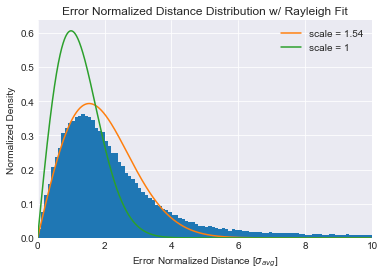

In [8]:
# Fit the Rayleigh Distribution in linear space, on a limited section of the data
fig, ax = plt.subplots(1,1, figsize=(6,4))
cutoff = 10
mask = error_w_distances < cutoff
n, bins, patch = ax.hist(error_w_distances[mask], density=True, bins=100)
bin_middles = np.zeros(n.shape[0])
for i in range(bin_middles.shape[0]):
    bin_middles[i] = bins[i] + 0.5 * (bins[i+1] - bins[i])
popt, pcov = curve_fit(rayleigh, bin_middles, n)
x = np.linspace(0, bin_middles[-1],10000)
sigma = popt[0]
ax.plot(x, rayleigh(x, *popt), label=f'scale = {sigma:.2f}')
ax.plot(x, rayleigh(x, 1), label='scale = 1')
ax.set_xlabel(r"Error Normalized Distance [$\sigma_{avg}$]")
ax.set_ylabel('Normalized Density')
ax.set_title('Error Normalized Distance Distribution w/ Rayleigh Fit')
print(bin_middles[np.argmax(n)])
ax.legend()
ax.set_xlim(0,10)
#plt.savefig(fpath+'marrese_ew+EIB+1p65_directionbased_distribution_rayleigh_fit.png', bbox_inches='tight')
plt.show()      

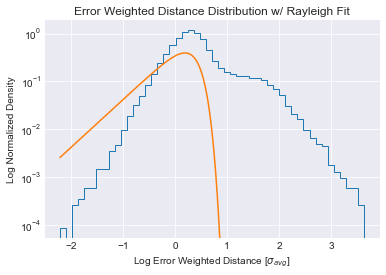

In [9]:
# Show this in log-log space
fig, ax = plt.subplots(1,1, figsize=(6,4))

x = np.logspace(np.log10(np.min(error_w_distances)), np.log10(np.max(error_w_distances)), 1000)

y_rayleigh = rayleigh(x, sigma)
rayleigh_mask = y_rayleigh > 1.0e-24 # very small numbers, or 0

ax.hist(np.log10(error_w_distances), log=True, histtype='step', density=True, bins=50)
ylims = ax.get_ylim()
ax.plot(np.log10(x[rayleigh_mask]), y_rayleigh[rayleigh_mask])

ax.set_ylim(ylims)

ax.set_xlabel(r'Log Error Weighted Distance [$\sigma_{avg}$]')
ax.set_ylabel('Log Normalized Density')
ax.set_title('Error Weighted Distance Distribution w/ Rayleigh Fit')


#plt.savefig(fpath+'marrese_ew_distribution_rayleigh_fit_loglog.png', bbox_inches='tight')
plt.show()

In [ ]:
# Instead of total error weighted distance, look at alpha error and dec error weighted distances
distances_mas = np.degrees(distances) * 3600 * 1e3
avg_hipp_errors = (1./np.sqrt(2)) * np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
avg_gaia_errors = (1./np.sqrt(2)) * np.sqrt((pos_gaia_table[:, 2])**2 + (pos_gaia_table[: ,3])**2)
avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)

avg_ra_errors = np.sqrt((pos_hipp_table[:, 2])**2 + (pos_gaia_table[:, 2])**2)
avg_de_errors = np.sqrt((pos_hipp_table[:, 3])**2 + (pos_gaia_table[:, 3])**2)

ra_error_w_distances = distances_mas / avg_ra_errors
de_error_w_distances = distances_mas / avg_de_errors

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

ax.hist(np.log10(ra_error_w_distances), log=True, histtype='step', density=True, label='RA Weighted')
ax.hist(np.log10(de_error_w_distances), log=True, histtype='step', density=True, label='Dec Weighted')

ax.set_xlabel(r'Log Error Weighted Distance [$\sigma_{avg}$]')
ax.set_ylabel('Log Normalized Density')
ax.set_title(r'Error Weighted Distance Comparison $\alpha$ vs. $\delta$')

ax.legend()
plt.savefig(fpath+'marrese_alpha_dec_ew_comparison', bbox_inches='tight')
plt.show()

These two distributions basically look the same. Thus we can just make use of the combined error weighted distances.

Now, search for some correlations of high ew distance with some other parameter:

In [ ]:
extra_gdata
#pos_gaia_table_full



In [10]:
mask_ew = np.log10(error_w_distances) > -5

C:\Users\Rens\AppData\Local\Temp/ipykernel_8884/2267541543.py:6: RuntimeWarning: divide by zero encountered in log10
  G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)
C:\Users\Rens\AppData\Local\Temp/ipykernel_8884/2267541543.py:6: RuntimeWarning: invalid value encountered in log10
  G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)


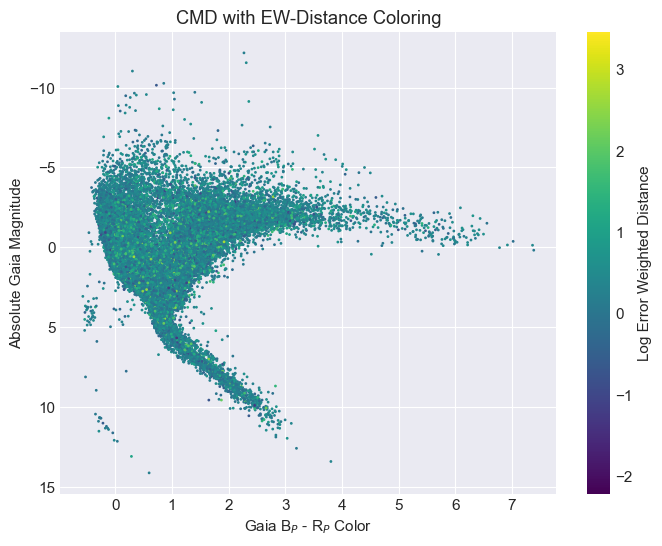

In [94]:
# Color Magnitude Diagram
G_app = marrese_gdata[:,0]
bp_rp = marrese_gdata[:,1]
plx = pos_gaia_table_full['parallax_prop']

G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)

fig, ax = plt.subplots(1,1, figsize=(8,6))
cmd = ax.scatter(bp_rp[mask_ew], G_abs[mask_ew], c=np.log10(error_w_distances[mask_ew]), cmap='viridis', s=1)
cb = plt.colorbar(cmd)

ax.set_xlabel(r'Gaia B$_P$ - R$_P$ Color')
ax.set_ylabel('Absolute Gaia Magnitude')
cb.set_label('Log Error Weighted Distance')
ax.set_title('CMD with EW-Distance Coloring')

ax.invert_yaxis()

plt.show()

In [ ]:
# Ruwe (error indicator)
ruwe = marrese_gdata[:, 6]

fig, ax = plt.subplots(1,1, figsize=(7,5))

mag_ruwe = ax.scatter(ruwe[mask_ew], G_app[mask_ew], cmap='viridis', c=np.log10(error_w_distances[mask_ew]), s=2)
cb = plt.colorbar(mag_ruwe)

ax.set_xlabel('Gaia ruwe')
ax.set_ylabel('Apparent G Magnitude')
cb.set_label('Log Error Weighted Distance')

plt.show()

In [ ]:
# Astrometric Properties
plx = pos_gaia_table_full['parallax_prop']
pm_tot = np.sqrt((marrese_gdata[:, 2])**2. + (marrese_gdata[:, 3])**2.)
gal_lat = marrese_gdata[:, 8]


fig, axs = plt.subplots(1,3, figsize=(12,4), tight_layout=True, sharey=True)

axs[0].scatter(gal_lat, np.log10(error_w_distances), s=2)
axs[1].scatter(np.log10(pm_tot), np.log10(error_w_distances), s=2)
axs[2].scatter(np.log10(plx), np.log10(error_w_distances), s=2)

axs[0].set_ylabel('Log Error Weighted Distance')
axs[0].set_xlabel('Galactic Latitude [deg]')
axs[1].set_xlabel('Log Total Proper Motion [mas/yr]')
axs[2].set_xlabel('Log Parallax [mas]')

axs[0].set_title('Galactic Latitude')
axs[1].set_title('Total Proper Motion')
axs[2].set_title('Parallax')
plt.show()

In [ ]:
# Sky Distribution
ra = pos_gaia_table_full['ra_prop']
de = pos_gaia_table_full['dec_prop']

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='hammer')
#fig, ax = plt.subplots(1,1, figsize=(8,6), projection='hammer')

pos = ax.scatter(ra[mask_ew], de[mask_ew], c=np.log10(error_w_distances[mask_ew]), cmap='viridis', s=1)
cb = plt.colorbar(pos)

ax.set_xlabel('RA (J1991.25) [deg]')
ax.set_ylabel('Dec (J1991.25) [deg]')
cb.set_label('Log Error Weighted Distance')

No correlations???

Compare distances between us and Marrese as reported on the Archive

In [ ]:
from data_queries import gaia_login, launch_job, get_data
query = 'SELECT angular_distance FROM gaiadr3.hipparcos2_best_neighbour'
job = launch_job(query)
distances_marrese = get_data(job)['angular_distance'] * 1e3 # arcseconds to mas

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(7,5))

ax.hist(np.log10(distances_mas), histtype='step', log=True, label='Kievit Distances', bins=25)
ax.hist(np.log10(distances_marrese), histtype='step', log=True, label='Marrese Distances', bins=25)

ax.set_xlabel('Distance between Matches [mas]')
ax.set_ylabel('Counts')
ax.set_title('Distance Comparison between Kievit and Marrese XM')

ax.legend()
plt.show()

C:\Users\Rens\AppData\Local\Temp/ipykernel_3092/3935913350.py:12: RuntimeWarning: divide by zero encountered in log10
  hexbin = ax.hexbin(np.log10(pma_snr), np.log10(error_w_distances),mincnt=1, cmap='viridis')


Top Left Corner:     562 objects
Top Right Corner:    11340 objects
Bottom Left Corner:  76446 objects
Bottom Right Corner: 8964 objects

High PMa SNR for Low D:  10.50%
High PMa SNR High D: 95.28%


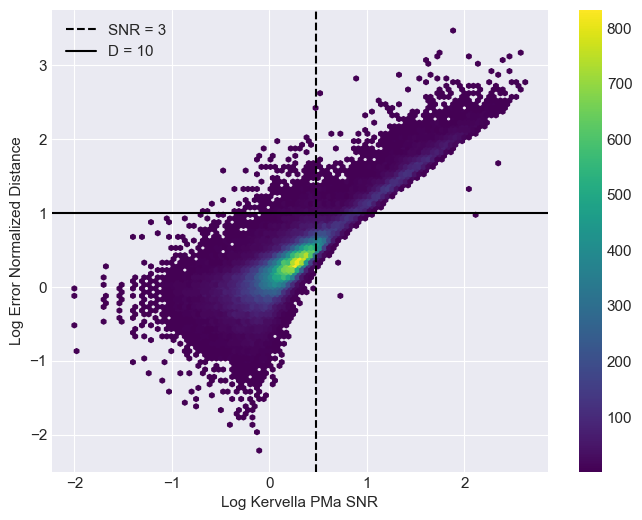

In [25]:
D_cutoff = 10
# Check D against the PMa binary indicator from Kervalla+21
kervella_tab = fits.open('../../../data/marrese_1as_xm_base_kervella_pma-result.fits')
np.array_equal(np.array(kervella_tab[1].data['hip'], dtype=int), marrese_xm_base[:,0])

pma_snr = kervella_tab[1].data['snrpmah2eg3b']
bin_flag = np.array(kervella_tab[1].data['binh2eg3b'])

#print(kervella_tab[1].header)
fig, ax = plt.subplots(1,1, figsize=(8,6))
#ax.scatter(np.log10(pma_snr), np.log10(error_w_distances), s=2, c=bin_flag, cmap='bwr')
hexbin = ax.hexbin(np.log10(pma_snr), np.log10(error_w_distances),mincnt=1, cmap='viridis')
plt.colorbar(hexbin)
ax.axvline(x=np.log10(3), c='black', ls='--', label='SNR = 3')
ax.axhline(y=np.log10(D_cutoff), c='black', label=f'D = {D_cutoff}')

ax.set_xlabel('Log Kervella PMa SNR')
ax.set_ylabel('Log Error Normalized Distance')

top_right = len(pma_snr[(pma_snr>3)*(error_w_distances>D_cutoff) ])
top_left = len(pma_snr[(pma_snr<3)*(error_w_distances>D_cutoff) ])
bot_right = len(pma_snr[(pma_snr>3)*(error_w_distances<D_cutoff) ])
bot_left = len(pma_snr[(pma_snr<3)*(error_w_distances<D_cutoff) ])

print(f'Top Left Corner:     {top_left} objects')
print(f'Top Right Corner:    {top_right} objects')
print(f'Bottom Left Corner:  {bot_left} objects')
print(f'Bottom Right Corner: {bot_right} objects')
print('')
print(f'High PMa SNR for Low D:  {100*bot_right/(bot_left+bot_right):.2f}%')
print(f'High PMa SNR High D: {100*top_right/(top_left+top_right):.2f}%')

plt.legend(loc='upper left')
#plt.savefig(fpath+'pma_snr_vs_d_scatter.png', bbox_inches='tight', transparent=True)

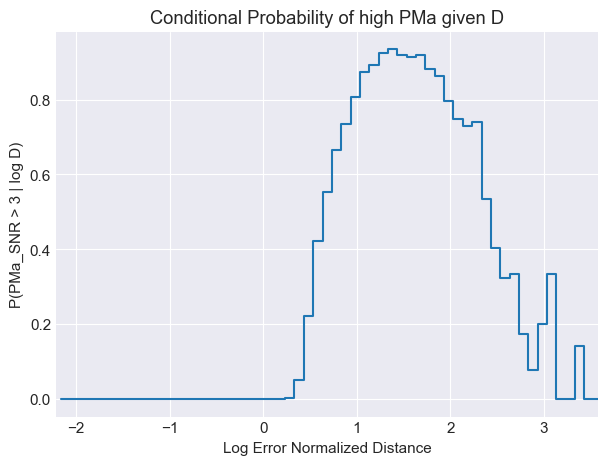

In [16]:
# probability that an object has pma_snr > 3, conditional on D
bin_width_log = 0.1
log_error_norm_distances = np.log10(error_w_distances)
bin_starts = np.arange(np.min(log_error_norm_distances), np.max(log_error_norm_distances), bin_width_log)
pma_snr_given_d = np.zeros_like(bin_starts)

for i in range(len(bin_starts)):
    bin_width_mask = (log_error_norm_distances > bin_starts[i]) * \
                     (log_error_norm_distances < bin_starts[i]+bin_width_log)

    num_in_mask = len(bin_flag[bin_width_mask])
    num_bin_flag = len(bin_flag[(bin_flag == 1) * bin_width_mask])

    if num_in_mask > 0:
        pma_snr_given_d[i] = num_bin_flag/num_in_mask
    else:
        pma_snr_given_d[i] = 0

fig, ax = plt.subplots(1,1,figsize=(7,5))
plt.step(bin_starts+(0.5*bin_width_log), pma_snr_given_d)

ax.set_xlabel('Log Error Normalized Distance')
ax.set_ylabel('P(PMa_SNR > 3 | log D)')
ax.set_title('Conditional Probability of high PMa given D')

ax.set_xlim(min(bin_starts), max(bin_starts))

plt.savefig(fpath+'conditional_prob_high_pma_given_d.png', bbox_inches='tight', transparent=True)



#### Conditional Probabilities

In [89]:
def compute_conditional_probability(xdata, con_data, xbins, con_bins):
    """Sets up a probability distribution of the xdata, given that con_data is within a certain range
    - xdata and con_data must have the same shape!"""
    distributions = np.zeros((len(con_bins)-1, len(xbins)-1)) # Each row contains a dist. with xbins entries for each con_bins
    for i in range(len(con_bins) - 1):
        conditional_mask = (con_data > con_bins[i]) * (con_data < con_bins[i+1])
        xdata_masked = xdata[conditional_mask]
        for j in range(len(xbins) - 1):
            xbin_mask = (xdata_masked >= xbins[j]) * (xdata_masked < xbins[j+1])
            distributions[i][j] = len(xdata_masked[xbin_mask]) / len(xdata_masked)

    return distributions

['phot_g_mean_mag', 'bp_rp', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error', 'ruwe', 'l', 'b']
4.5
3


C:\Users\Rens\AppData\Local\Temp/ipykernel_8884/1179857690.py:13: RuntimeWarning: invalid value encountered in log10
  xdata = np.log10(marrese_gdata[:,i])


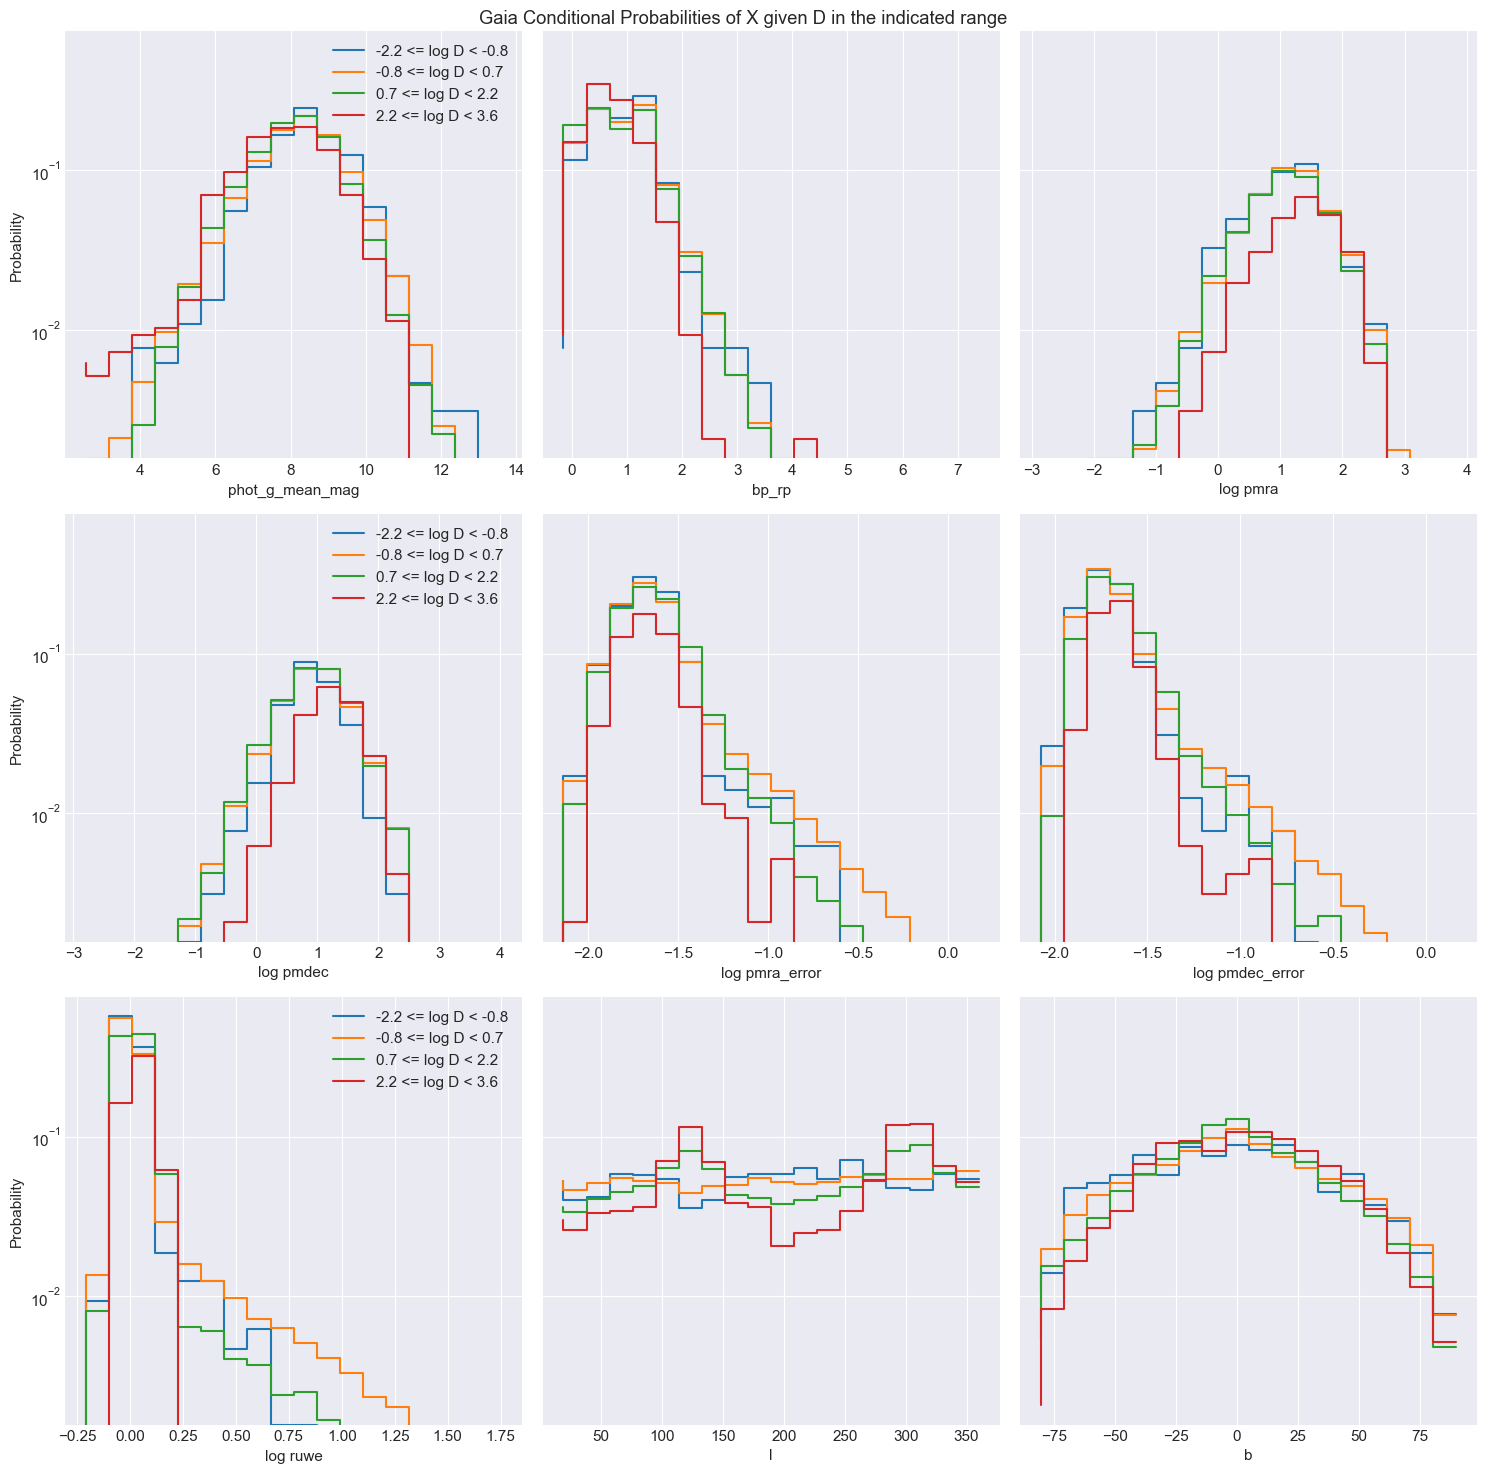

In [128]:
print(extra_gdata)
do_log = [False, False, True, True, True, True, True, False, False]
num_params = len(extra_gdata)
print(num_params/2)
dim = int(np.ceil(np.sqrt(num_params))) # Might change this later. For now a square is good
print(dim)
fig, axs = plt.subplots(dim,dim,figsize=(15,15), sharey=True, tight_layout=True)

D_bins = np.linspace(np.min(log_error_norm_distances), np.max(log_error_norm_distances), 5)

for i, ax in enumerate(axs.flatten()):
    if do_log[i]:
        xdata = np.log10(marrese_gdata[:,i])
        xlabel = f'log {extra_gdata[i]}'
    else:
        xdata = marrese_gdata[:,i]
        xlabel = extra_gdata[i]

    xbins = np.linspace(np.nanmin(xdata), np.nanmax(xdata), 20)
    bin_width = xbins[1] - xbins[0]

    distributions = compute_conditional_probability(xdata, log_error_norm_distances, xbins, D_bins)
    for j in range(distributions.shape[0]):
        label = f'{D_bins[j]:.1f} <= log D < {D_bins[j+1]:.1f}'
        if (i % dim) == 0:
            ax.step(xbins[:-1] + bin_width, distributions[j], label=label)
        else:
            ax.step(xbins[:-1] + bin_width, distributions[j])

    ax.set_xlabel(xlabel)
    if (i % dim) == 0:
        ax.set_ylabel('Probability')
        ax.legend()

    ax.set_yscale('log')

plt.suptitle('Gaia Conditional Probabilities of X given D in the indicated range')
plt.savefig(fpath+'Gaia_conditionals.png', bbox_inches='tight', transparent=True)
plt.show()

['hp_mag', 'b_v', 'f1', 'f2']
['phot_g_mean_mag', 'bp_rp', 'pmra', 'pmdec', 'pmra_error', 'pmdec_error', 'ruwe', 'l', 'b']
2


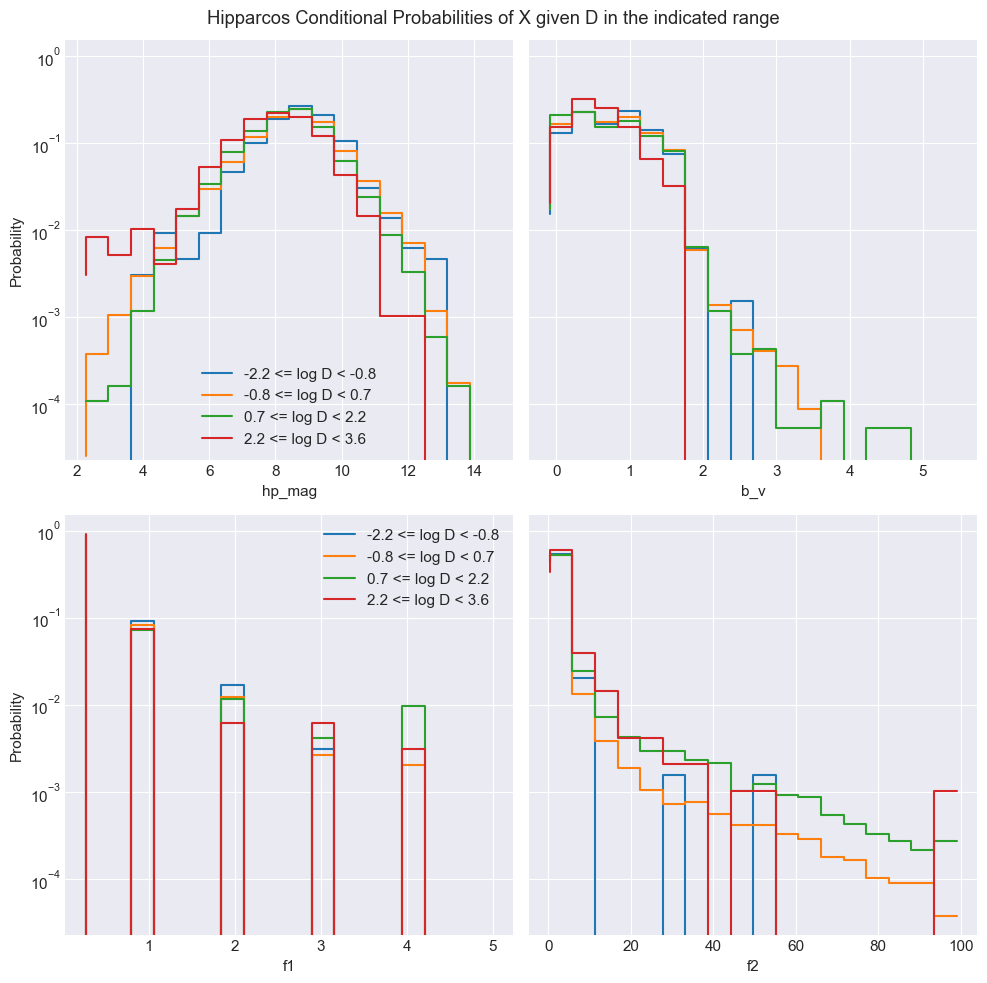

In [129]:
# Same as above but with Hipparcos parameters
print(extra_hdata)

print(extra_gdata)
do_log = [False, False, False, False]
num_params = len(extra_hdata)
dim = int(np.ceil(np.sqrt(num_params))) # Might change this later. For now a square is good
print(dim)
fig, axs = plt.subplots(dim,dim,figsize=(dim*5, dim*5), sharey=True, tight_layout=True)

D_bins = np.linspace(np.min(log_error_norm_distances), np.max(log_error_norm_distances), 5)

for i, ax in enumerate(axs.flatten()):
    if do_log[i]:
        xdata = np.log10(marrese_hdata[:,i])
        xlabel = f'log {extra_hdata[i]}'
    else:
        xdata = marrese_hdata[:,i]
        xlabel = extra_hdata[i]

    xbins = np.linspace(np.nanmin(xdata), np.nanmax(xdata), 20)
    bin_width = xbins[1] - xbins[0]

    distributions = compute_conditional_probability(xdata, log_error_norm_distances, xbins, D_bins)
    for j in range(distributions.shape[0]):
        label = f'{D_bins[j]:.1f} <= log D < {D_bins[j+1]:.1f}'
        if (i % dim) == 0:
            ax.step(xbins[:-1] + bin_width, distributions[j], label=label)
        else:
            ax.step(xbins[:-1] + bin_width, distributions[j])

    ax.set_xlabel(xlabel)
    if (i % dim) == 0:
        ax.set_ylabel('Probability')
        ax.legend()

    ax.set_yscale('log')

plt.suptitle('Hipparcos Conditional Probabilities of X given D in the indicated range')
plt.savefig(fpath+'Hipp_conditionals.png', bbox_inches='tight', transparent=True)
plt.show()

AttributeError: 'AxesSubplot' object has no attribute 'flatten'

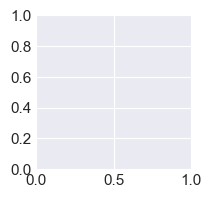

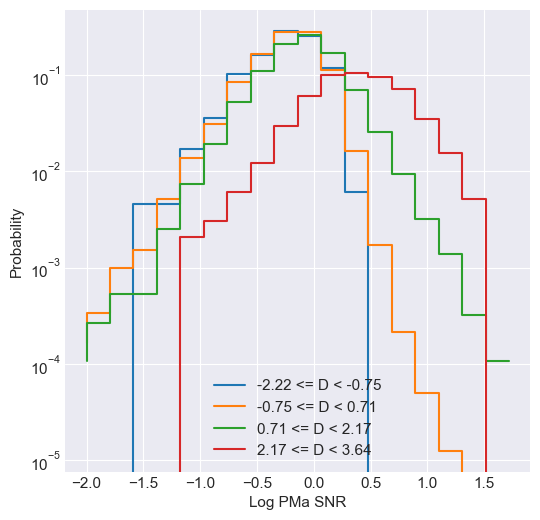

In [107]:
# TEST WITH PMA SNR
# when taking log, mask out all of the NaN and 0 points as they break
log_pma_snr = copy.deepcopy(pma_snr)
log_pma_snr[~(log_pma_snr > 0 )] = np.nan
log_pma_snr = np.log10(log_pma_snr)
#print(np.nanmin(pma_snr))
pma_snr_binstarts = np.linspace(np.nanmin(log_pma_snr), np.nanmax(log_pma_snr), 20)

D_binstarts = np.linspace(np.min(log_error_norm_distances), np.max(log_error_norm_distances), 5)
#D_binstarts = [-2, -0.5, 1, 2.5, 4]

distributions = compute_conditional_probability(log_pma_snr, log_error_norm_distances, pma_snr_binstarts, D_binstarts)
fig, ax = plt.subplots(1,1, figsize=(6,6))
for i in range(distributions.shape[0]):
    label = f'{D_binstarts[i]:.2f} <= D < {D_binstarts[i+1]:.2f}'
    ax.step(pma_snr_binstarts[:-1], distributions[i], label=label)
#print(distributions)
ax.set_ylabel('Probability')
ax.set_xlabel('Log PMa SNR')

ax.set_yscale('log')

plt.legend()
plt.show()

1.9425238370895386
[ 1.94252384  2.5561573   3.16979076  3.78342423  4.39705769  5.01069115
  5.62432462  6.23795808  6.85159154  7.46522501  8.07885847  8.69249193
  9.3061254   9.91975886 10.53339232 11.14702579 11.76065925 12.37429271
 12.98792618 13.60155964]


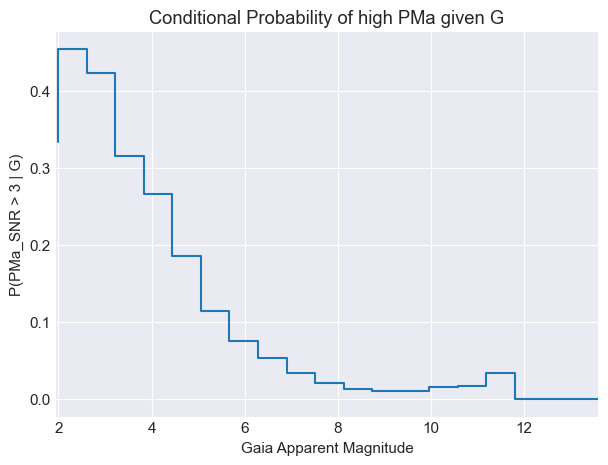

In [123]:
# probability that an object has pma_snr > 3, conditional on G
#bin_width_log = 0.1
#log_error_norm_distances = np.log10(error_w_distances)
print(np.nanmin(G_app))
bin_starts = np.linspace(np.nanmin(G_app[np.isfinite(G_app)]), np.nanmax(G_app[np.isfinite(G_app)]), 20)
print(bin_starts)
bin_width = bin_starts[1] - bin_starts[0]
pma_snr_given_G = np.zeros_like(bin_starts)


for i in range(len(bin_starts)-1):
    bin_width_mask = (G_app > bin_starts[i]) * (G_app < bin_starts[i+1])

    num_in_mask = len(bin_flag[bin_width_mask])
    num_bin_flag = len(bin_flag[(bin_flag == 1) * bin_width_mask])

    if num_in_mask > 0:
        pma_snr_given_G[i] = num_bin_flag/num_in_mask
    else:
        pma_snr_given_G[i] = 0

fig, ax = plt.subplots(1,1,figsize=(7,5))
plt.step(bin_starts+(0.5*bin_width_log), pma_snr_given_G)

ax.set_xlabel('Gaia Apparent Magnitude')
ax.set_ylabel('P(PMa_SNR > 3 | G)')
ax.set_title('Conditional Probability of high PMa given G')

ax.set_xlim(min(bin_starts), max(bin_starts))

plt.savefig(fpath+'conditional_prob_high_pma_given_G.png', bbox_inches='tight', transparent=True)

In [115]:
np.sort(-G_abs)

array([-14.12454251, -13.41081669, -13.09210596, ...,          nan,
                nan,          nan])

### Test PMC with the Marrese stars

In [ ]:
pos_gaia_params = ['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'parallax_prop', 'pmra_prop', 'pmdec_prop', 'phot_g_mean_mag', 'bp_rp']
pos_hipp_params = ['ra', 'dec', 'e_ra_rad', 'e_de_rad']
marrese_xm_base = np.load('../../results/marrese_crossmatch+EIB_1as_best_neighbour_nearest.npy')
marrese_xm_pmc = np.load('../../results/marrese_crossmatch+PMC+EIB_1as_best_neighbour_nearest.npy')

#_, pos_hipp_table_base = query_extra_data(marrese_xm_base, pos_hipp_params, cat='hipp')
#_, pos_hipp_table_pmc = query_extra_data(marrese_xm_pmc, pos_hipp_params, cat='hipp')

cat_gaia_base = fits.open(f'../../../data/GaiaBaseCat+EIB.fits')[1].data
cat_gaia_pmc = fits.open(f'../../../data/GaiaBaseCat+PMC+EIB.fits')[1].data


# This for loop populates the pos_gaia table following GaiaCat_ID in the xm tables.
pos_gaia_table_base = np.zeros((marrese_xm_base.shape[0], len(pos_gaia_params)))
pos_gaia_table_pmc = np.zeros((marrese_xm_pmc.shape[0], len(pos_gaia_params)))

for i, label in enumerate(pos_gaia_params):
    print(label)
    pos_gaia_table_base[:, i] = cat_gaia_base[label][marrese_xm_base[:,2]]
    pos_gaia_table_pmc[:, i] = cat_gaia_pmc[label][marrese_xm_pmc[:,2]]

In [ ]:
# Base Cat
ra_a = np.radians(pos_hipp_table[:,0])
dec_a = np.radians(pos_hipp_table[:,1])
ra_b = np.radians(pos_gaia_table_base[:,0])
dec_b = np.radians(pos_gaia_table_base[:,1])
distances = angular_distance(ra_a, dec_a, ra_b, dec_b)

distances_mas_base = np.degrees(distances) * 3600 * 1e3
avg_hipp_errors = (1./np.sqrt(2)) * np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
avg_gaia_errors = (1./np.sqrt(2)) * np.sqrt((pos_gaia_table_base[:, 2])**2 + (pos_gaia_table_base[: ,3])**2)
avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
error_w_distances_base = distances_mas_base / avg_errors

# PMC Cat
ra_a = np.radians(pos_hipp_table[:,0])
dec_a = np.radians(pos_hipp_table[:,1])
ra_b = np.radians(pos_gaia_table_pmc[:,0])
dec_b = np.radians(pos_gaia_table_pmc[:,1])
distances = angular_distance(ra_a, dec_a, ra_b, dec_b)

distances_mas_pmc = np.degrees(distances) * 3600 * 1e3
avg_hipp_errors = (1./np.sqrt(2)) * np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
avg_gaia_errors = (1./np.sqrt(2)) * np.sqrt((pos_gaia_table_pmc[:, 2])**2 + (pos_gaia_table_pmc[: ,3])**2)
avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
error_w_distances_pmc = distances_mas_pmc / avg_errors

In [ ]:
print(np.array_equal(marrese_xm_base[:,0], marrese_xm_pmc[:,0])) # Hipparcos the same
print(np.array_equal(marrese_xm_base[:,1], marrese_xm_pmc[:,1])) # Gaia the same

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

delta_distance = error_w_distances_base - error_w_distances_pmc
#delta_distance = distances_mas_base - distances_mas_pmc
ax.hist(delta_distance, bins=50)

ax.set_xlabel(r'EW_Dist$_{EIB}$ - EW_Dist$_{PMC+EIB}$')
ax.set_ylabel('Counts')
ax.set_title('Effect of PMC on Match Distance')

plt.show()

In [ ]:
mask_dd = delta_distance > -5

In [ ]:
# Sky Distribution
ra = pos_gaia_table_base[:,0]
de = pos_gaia_table_base[:,1]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='hammer')
#fig, ax = plt.subplots(1,1, figsize=(8,6), projection='hammer')

pos = ax.scatter(ra[mask_dd], de[mask_dd], c=delta_distance[mask_dd], cmap='viridis', s=1)
cb = plt.colorbar(pos)

ax.set_xlabel('RA (J1991.25) [deg]')
ax.set_ylabel('Dec (J1991.25) [deg]')
cb.set_label(r'EW_Dist$_{EIB}$ - EW_Dist$_{PMC+EIB}$')

In [ ]:

# Color Magnitude Diagram
G_app = pos_gaia_table_base[:,7]
bp_rp = pos_gaia_table_pmc[:,8]
plx = pos_gaia_table_base[:,4]

G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)

fig, ax = plt.subplots(1,1, figsize=(8,6))
cmd = ax.scatter(bp_rp[mask_dd], G_abs[mask_dd], c=delta_distance[mask_dd], cmap='viridis', s=1)
cb = plt.colorbar(cmd)

ax.set_xlabel(r'Gaia B$_P$ - R$_P$ Color')
ax.set_ylabel('Absolute Gaia Magnitude')
cb.set_label(r'EW_Dist$_{EIB}$ - EW_Dist$_{PMC+EIB}$')
ax.set_title('CMD with Delta-Distance Coloring')

ax.invert_yaxis()
ax.set_xlim(-1, 7.5)

plt.show()

In [ ]:
#mask_dd = delta_distance < 0
fig, ax = plt.subplots(1,1,figsize=(6,5))

pmra = pos_gaia_table_base[:,5]
pmde = pos_gaia_table_base[:,6]

pm_plot = ax.scatter(np.log10(pmra[mask_dd]), np.log10(pmde[mask_dd]), c=delta_distance[mask_dd], s=2, cmap='viridis')
cb = plt.colorbar(pm_plot)

ax.set_xlabel('Log RA Proper Motion [mas/yr]')
ax.set_ylabel('Log Dec Proper Motion [mas/yr]')
cb.set_label(r'EW_Dist$_{EIB}$ - EW_Dist$_{PMC+EIB}$')

These two distributions basically look the same. Thus we can just make use of the combined error weighted distances.

Now, search for some correlations of high ew distance with some other parameter:

In [292]:
extra_gdata
#pos_gaia_table_full



['phot_g_mean_mag',
 'bp_rp',
 'pmra',
 'pmdec',
 'pmra_error',
 'pmdec_error',
 'ruwe',
 'l',
 'b']

In [27]:
mask_ew = np.log10(error_w_distances) > -10

<ipython-input-341-c722945abe38>:6: RuntimeWarning: divide by zero encountered in log10
  G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)
<ipython-input-341-c722945abe38>:6: RuntimeWarning: invalid value encountered in log10
  G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)


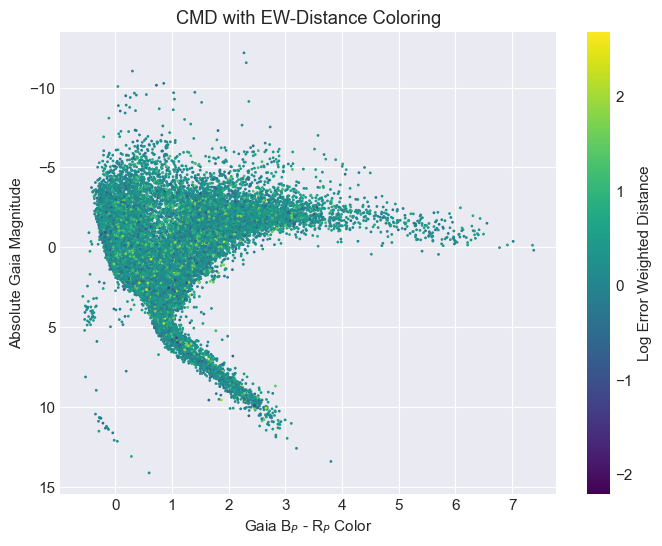

In [341]:
# Color Magnitude Diagram
G_app = marrese_gdata[:,0]
bp_rp = marrese_gdata[:,1]
plx = pos_gaia_table_full['parallax_prop']

G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)

fig, ax = plt.subplots(1,1, figsize=(8,6))
cmd = ax.scatter(bp_rp[mask_ew], G_abs[mask_ew], c=np.log10(error_w_distances[mask_ew]), cmap='viridis', s=1)
cb = plt.colorbar(cmd)

ax.set_xlabel(r'Gaia B$_P$ - R$_P$ Color')
ax.set_ylabel('Absolute Gaia Magnitude')
cb.set_label('Log Error Weighted Distance')
ax.set_title('CMD with EW-Distance Coloring')

ax.invert_yaxis()

plt.show()

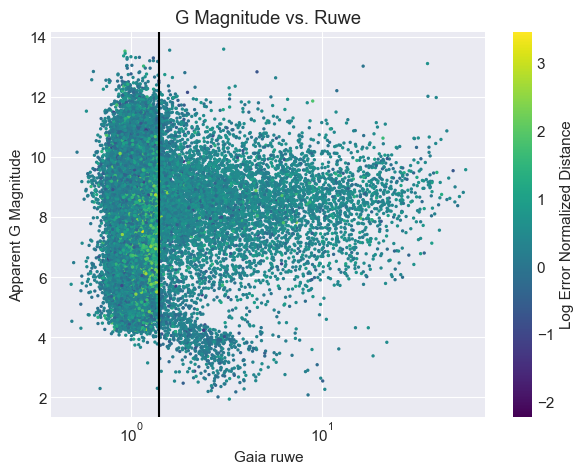

In [100]:
# Ruwe (error indicator)
ruwe = marrese_gdata[:, 6]

fig, ax = plt.subplots(1,1, figsize=(7,5))

mag_ruwe = ax.scatter(ruwe[mask_ew], G_app[mask_ew], cmap='viridis', c=np.log10(error_w_distances[mask_ew]), s=2)
cb = plt.colorbar(mag_ruwe)
ax.axvline(x=1.4, c='black')

ax.set_xlabel('Gaia ruwe')
ax.set_ylabel('Apparent G Magnitude')
cb.set_label('Log Error Normalized Distance')
ax.set_title('G Magnitude vs. Ruwe')

ax.set_xscale('log')

plt.savefig(fpath+'error_norm_distance_G_vs_ruwe.png', bbox_inches='tight', transparent=True)
plt.show()

C:\Users\Rens\AppData\Local\Temp/ipykernel_8312/473644655.py:12: RuntimeWarning: divide by zero encountered in log10
  axs[2].scatter(np.log10(plx), np.log10(error_w_distances), s=size)
C:\Users\Rens\AppData\Local\Temp/ipykernel_8312/473644655.py:12: RuntimeWarning: invalid value encountered in log10
  axs[2].scatter(np.log10(plx), np.log10(error_w_distances), s=size)


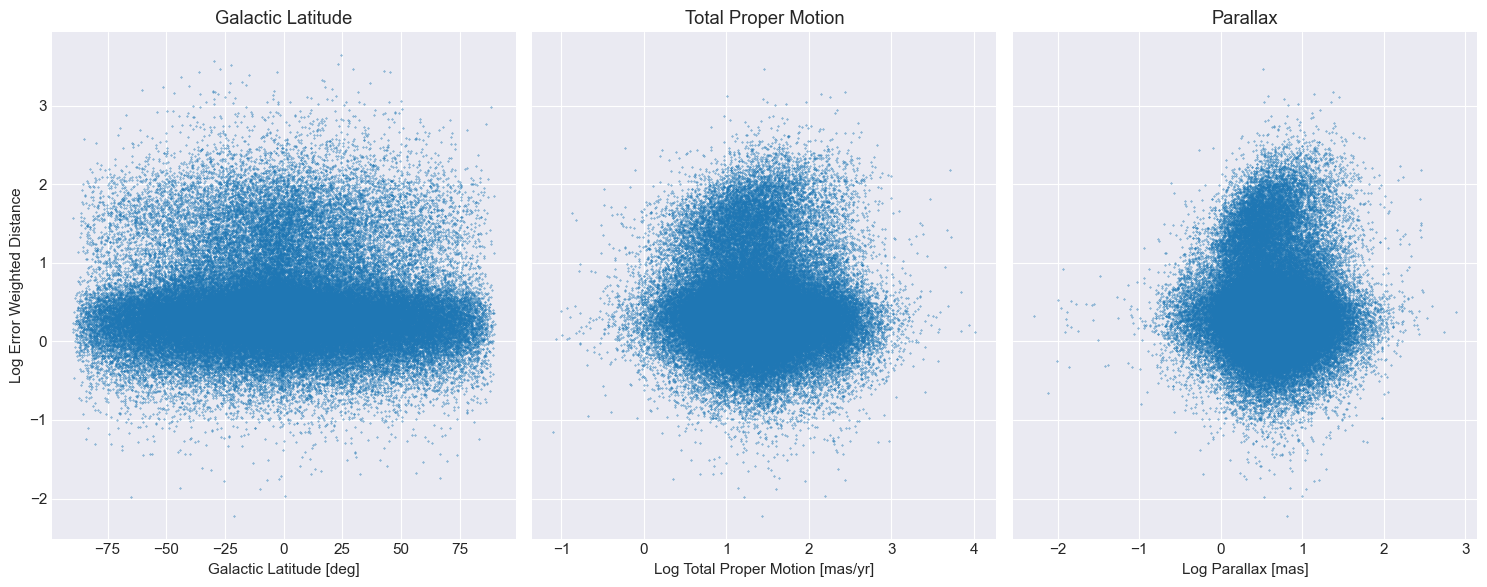

In [101]:
# Astrometric Properties
plx = pos_gaia_table_full['parallax_prop']
pm_tot = np.sqrt((marrese_gdata[:, 2])**2. + (marrese_gdata[:, 3])**2.)
gal_lat = marrese_gdata[:, 8]


fig, axs = plt.subplots(1,3, figsize=(15,6), tight_layout=True, sharey=True)

size=0.1
axs[0].scatter(gal_lat, np.log10(error_w_distances), s=size)
axs[1].scatter(np.log10(pm_tot), np.log10(error_w_distances), s=size)
axs[2].scatter(np.log10(plx), np.log10(error_w_distances), s=size)

axs[0].set_ylabel('Log Error Weighted Distance')
axs[0].set_xlabel('Galactic Latitude [deg]')
axs[1].set_xlabel('Log Total Proper Motion [mas/yr]')
axs[2].set_xlabel('Log Parallax [mas]')

axs[0].set_title('Galactic Latitude')
axs[1].set_title('Total Proper Motion')
axs[2].set_title('Parallax')
plt.savefig(fpath+'error_norm_distance_various.png', bbox_inches='tight', transparent=True)
plt.show()

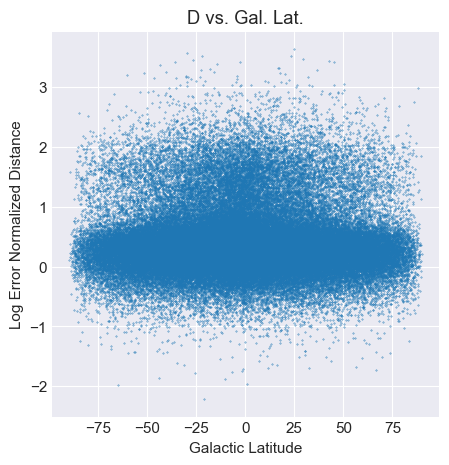

In [102]:
# Only Galactic Latitude
fig, ax = plt.subplots(1,1,figsize=(5,5))

ax.scatter(gal_lat, np.log10(error_w_distances), s=0.1)

ax.set_xlabel('Galactic Latitude')
ax.set_ylabel('Log Error Normalized Distance')
ax.set_title('D vs. Gal. Lat.')

plt.savefig(fpath+'error_norm_distance_vs_gallat.png', bbox_inches='tight', transparent=True)
plt.show()

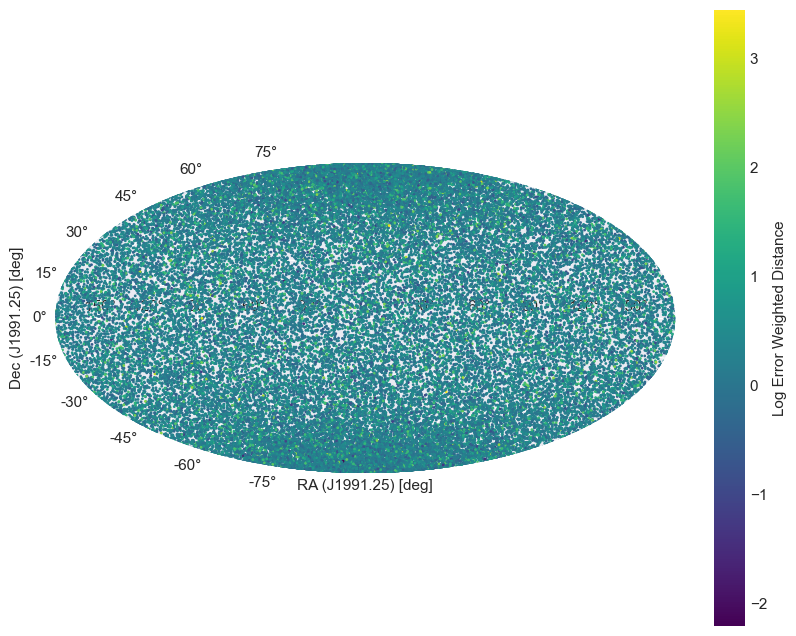

In [344]:
# Sky Distribution
ra = pos_gaia_table_full['ra_prop']
de = pos_gaia_table_full['dec_prop']

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='hammer')
#fig, ax = plt.subplots(1,1, figsize=(8,6), projection='hammer')

pos = ax.scatter(ra[mask_ew], de[mask_ew], c=np.log10(error_w_distances[mask_ew]), cmap='viridis', s=1)
cb = plt.colorbar(pos)

ax.set_xlabel('RA (J1991.25) [deg]')
ax.set_ylabel('Dec (J1991.25) [deg]')
cb.set_label('Log Error Weighted Distance')

No correlations???

Compare distances between us and Marrese as reported on the Archive

In [334]:
from data_queries import gaia_login, launch_job, get_data
query = 'SELECT angular_distance FROM gaiadr3.hipparcos2_best_neighbour'
job = launch_job(query)
distances_marrese = get_data(job)['angular_distance'] * 1e3 # arcseconds to mas

INFO: Query finished. [astroquery.utils.tap.core]


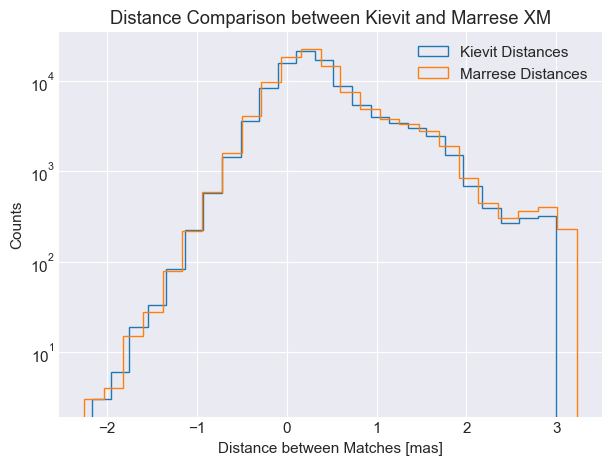

In [346]:
fig, ax = plt.subplots(1,1, figsize=(7,5))

ax.hist(np.log10(distances_mas), histtype='step', log=True, label='Kievit Distances', bins=25)
ax.hist(np.log10(distances_marrese), histtype='step', log=True, label='Marrese Distances', bins=25)

ax.set_xlabel('Distance between Matches [mas]')
ax.set_ylabel('Counts')
ax.set_title('Distance Comparison between Kievit and Marrese XM')

ax.legend()
plt.show()

### Test PMC with the Marrese stars

In [46]:
pos_gaia_params = ['ra_prop', 'dec_prop', 'e_ra_prop', 'e_de_prop', 'parallax_prop', 'pmra_prop', 'pmdec_prop', 'phot_g_mean_mag', 'bp_rp']
pos_hipp_params = ['ra', 'dec', 'e_ra_rad', 'e_de_rad']
marrese_xm_base = np.load('../../results/marrese_crossmatch+EIB_1as_best_neighbour_nearest.npy')
marrese_xm_pmc = np.load('../../results/marrese_crossmatch+PMC+EIB_1as_best_neighbour_nearest.npy')

#_, pos_hipp_table_base = query_extra_data(marrese_xm_base, pos_hipp_params, cat='hipp')
#_, pos_hipp_table_pmc = query_extra_data(marrese_xm_pmc, pos_hipp_params, cat='hipp')

cat_gaia_base = fits.open(f'../../../data/GaiaBaseCat+EIB.fits')[1].data
cat_gaia_pmc = fits.open(f'../../../data/GaiaBaseCat+PMC+EIB.fits')[1].data


# This for loop populates the pos_gaia table following GaiaCat_ID in the xm tables.
pos_gaia_table_base = np.zeros((marrese_xm_base.shape[0], len(pos_gaia_params)))
pos_gaia_table_pmc = np.zeros((marrese_xm_pmc.shape[0], len(pos_gaia_params)))

for i, label in enumerate(pos_gaia_params):
    print(label)
    pos_gaia_table_base[:, i] = cat_gaia_base[label][marrese_xm_base[:,2]]
    pos_gaia_table_pmc[:, i] = cat_gaia_pmc[label][marrese_xm_pmc[:,2]]

ra_prop
dec_prop
e_ra_prop
e_de_prop
parallax_prop
pmra_prop
pmdec_prop
phot_g_mean_mag
bp_rp


In [66]:
_, extra_gdata_base = query_extra_data(marrese_xm_base, ['l', 'b'])
_, extra_gdata_pmc = query_extra_data(marrese_xm_pmc, ['l', 'b'])

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


In [57]:
# Base Cat
ra_a = np.radians(pos_hipp_table[:,0])
dec_a = np.radians(pos_hipp_table[:,1])
ra_b = np.radians(pos_gaia_table_base[:,0])
dec_b = np.radians(pos_gaia_table_base[:,1])
distances = angular_distance(ra_a, dec_a, ra_b, dec_b)

distances_mas_base = np.degrees(distances) * 3600 * 1e3
avg_hipp_errors = (1./np.sqrt(2)) * np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
avg_gaia_errors = (1./np.sqrt(2)) * np.sqrt((pos_gaia_table_base[:, 2])**2 + (pos_gaia_table_base[: ,3])**2)
avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
error_w_distances_base = distances_mas_base / avg_errors

# PMC Cat
ra_a = np.radians(pos_hipp_table[:,0])
dec_a = np.radians(pos_hipp_table[:,1])
ra_b = np.radians(pos_gaia_table_pmc[:,0])
dec_b = np.radians(pos_gaia_table_pmc[:,1])
distances = angular_distance(ra_a, dec_a, ra_b, dec_b)

distances_mas_pmc = np.degrees(distances) * 3600 * 1e3
avg_hipp_errors = (1./np.sqrt(2)) * np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
avg_gaia_errors = (1./np.sqrt(2)) * np.sqrt((pos_gaia_table_pmc[:, 2])**2 + (pos_gaia_table_pmc[: ,3])**2)
avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
error_w_distances_pmc = distances_mas_pmc / avg_errors

In [58]:
print(np.array_equal(marrese_xm_base[:,0], marrese_xm_pmc[:,0])) # Hipparcos the same
print(np.array_equal(marrese_xm_base[:,1], marrese_xm_pmc[:,1])) # Gaia the same

True
True


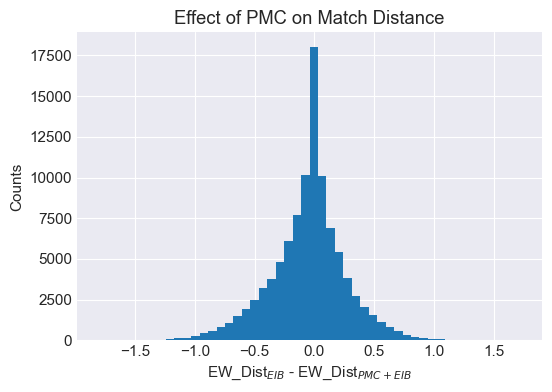

In [103]:
fig, ax = plt.subplots(1,1, figsize=(6,4))

delta_distance = error_w_distances_base - error_w_distances_pmc
#delta_distance = distances_mas_base - distances_mas_pmc
ax.hist(delta_distance, bins=50)

ax.set_xlabel(r'EW_Dist$_{EIB}$ - EW_Dist$_{PMC+EIB}$')
ax.set_ylabel('Counts')
ax.set_title('Effect of PMC on Match Distance')

plt.savefig(fpath+'error_norm_distance_PMC_effect.png', bbox_inches='tight', transparent=True)
plt.show()

In [62]:
print(f"In total {len(delta_distance[np.abs(delta_distance) > 1.5])} have abs(delta_distance) > 1.5")
print(np.sort(delta_distance[np.abs(delta_distance) > 1.5]))

In total 25 have abs(delta_distance) > 1.5
[-1.81030579 -1.79658741 -1.71100583 -1.63692125 -1.61550637 -1.603731
 -1.57954131 -1.55676986 -1.55622625 -1.55584196 -1.54905488 -1.54050506
 -1.53585649 -1.53544182 -1.51094586  1.50169311  1.51652209  1.52052344
  1.55431329  1.57340683  1.60032818  1.65945005  1.71750626  1.72562716
  1.72893401]


In [63]:
mask_dd = delta_distance > -5

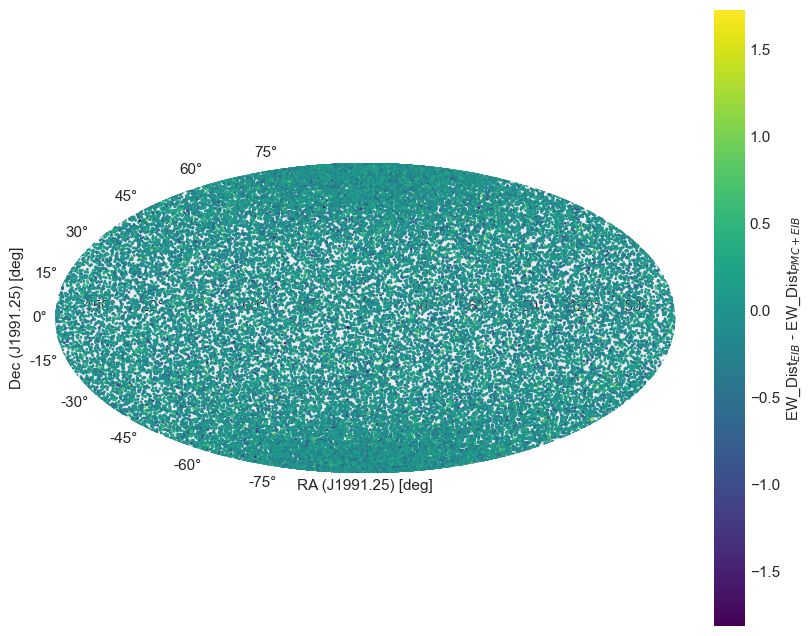

In [62]:
# Sky Distribution
ra = pos_gaia_table_base[:,0]
de = pos_gaia_table_base[:,1]

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(projection='hammer')
#fig, ax = plt.subplots(1,1, figsize=(8,6), projection='hammer')

pos = ax.scatter(ra[mask_dd], de[mask_dd], c=delta_distance[mask_dd], cmap='viridis', s=1)
cb = plt.colorbar(pos)

ax.set_xlabel('RA (J1991.25) [deg]')
ax.set_ylabel('Dec (J1991.25) [deg]')
cb.set_label(r'EW_Dist$_{EIB}$ - EW_Dist$_{PMC+EIB}$')

<ipython-input-61-f335a78c33db>:6: RuntimeWarning: divide by zero encountered in log10
  G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)
<ipython-input-61-f335a78c33db>:6: RuntimeWarning: invalid value encountered in log10
  G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)


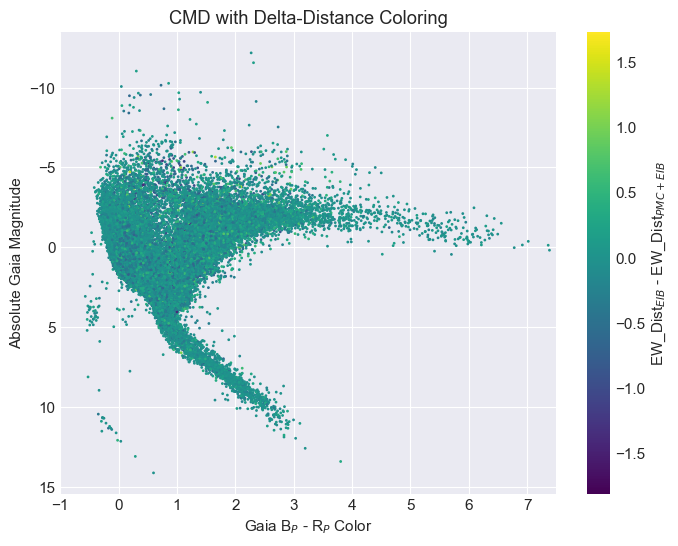

In [61]:
# Color Magnitude Diagram
G_app = pos_gaia_table_base[:,7]
bp_rp = pos_gaia_table_pmc[:,8]
plx = pos_gaia_table_base[:,4]

G_abs = G_app + 5.*(np.log10(1e-3*plx) + 1.)

fig, ax = plt.subplots(1,1, figsize=(8,6))
cmd = ax.scatter(bp_rp[mask_dd], G_abs[mask_dd], c=delta_distance[mask_dd], cmap='viridis', s=1)
cb = plt.colorbar(cmd)

ax.set_xlabel(r'Gaia B$_P$ - R$_P$ Color')
ax.set_ylabel('Absolute Gaia Magnitude')
cb.set_label(r'EW_Dist$_{EIB}$ - EW_Dist$_{PMC+EIB}$')
ax.set_title('CMD with Delta-Distance Coloring')

ax.invert_yaxis()
ax.set_xlim(-1, 7.5)

plt.show()

<ipython-input-60-6114f5da921c>:7: RuntimeWarning: divide by zero encountered in log10
  pm_plot = ax.scatter(np.log10(pmra[mask_dd]), np.log10(pmde[mask_dd]), c=delta_distance[mask_dd], s=2, cmap='viridis')
<ipython-input-60-6114f5da921c>:7: RuntimeWarning: invalid value encountered in log10
  pm_plot = ax.scatter(np.log10(pmra[mask_dd]), np.log10(pmde[mask_dd]), c=delta_distance[mask_dd], s=2, cmap='viridis')


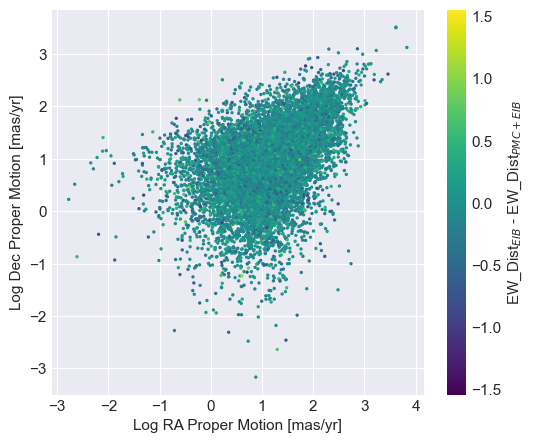

In [60]:
#mask_dd = delta_distance < 0
fig, ax = plt.subplots(1,1,figsize=(6,5))

pmra = pos_gaia_table_base[:,5]
pmde = pos_gaia_table_base[:,6]

pm_plot = ax.scatter(np.log10(pmra[mask_dd]), np.log10(pmde[mask_dd]), c=delta_distance[mask_dd], s=2, cmap='viridis')
cb = plt.colorbar(pm_plot)

ax.set_xlabel('Log RA Proper Motion [mas/yr]')
ax.set_ylabel('Log Dec Proper Motion [mas/yr]')
cb.set_label(r'EW_Dist$_{EIB}$ - EW_Dist$_{PMC+EIB}$')

In [67]:
extra_gdata_base

array([[ 63.11893094, -75.95902608],
       [112.09006636, -22.92758404],
       [320.79224474, -63.41550437],
       ...,
       [273.671218  , -15.85754525],
       [273.66732566, -15.81886983],
       [273.68700441, -15.79360732]])

In [137]:
mask_dd = np.abs(delta_distance) > 1
#mask_dd = delta_distance > 0.5
print(len(mask_dd[mask_dd]))

758


In [89]:
import matplotlib.projections
matplotlib.projections.get_projection_names()

['3d', 'aitoff', 'hammer', 'lambert', 'mollweide', 'polar', 'rectilinear']

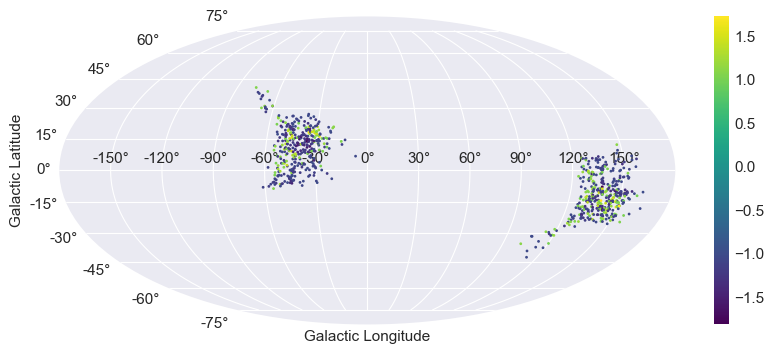

In [138]:
# Look at PMC Effect distribution vs. galactic lon v. lat
fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(projection='mollweide')

# convert degrees -> radians
lb_dd = ax.scatter((extra_gdata_base[:,0][mask_dd]-180) * (np.pi/180), extra_gdata_base[:,1][mask_dd] * (np.pi/180), c=delta_distance[mask_dd], s=1, cmap='viridis')
#lb_dd = ax.scatter(extra_gdata_base[:,0][mask_dd], extra_gdata_base[:,1][mask_dd] , c=delta_distance[mask_dd], s=10, cmap='viridis')
plt.colorbar(lb_dd)

#ax.set_xlim(0, 360)
#ax.set_ylim(-90, 90)

ax.set_xlabel('Galactic Longitude')
ax.set_ylabel('Galactic Latitude')
ax.invert_yaxis()
plt.savefig(fpath+'pmc_effect_large_l_vs_b_mollweide_lim1.png', bbox_inches='tight', transparent=True)

### Do the above code en mass for all four catalogues with an XM at a certain radius

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. 

...

INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. 

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.
INFO: Login to gaia TAP server [astroquery.gaia.core]
OK
INFO: Login to gaia data server [astroquery.gaia.core]
OK
Sending pytable.
Uploaded table 'xm_table'.
INFO: Query finished. [astroquery.utils.tap.core]
Post data query array is not shuffled
Table 'xm_table' deleted.


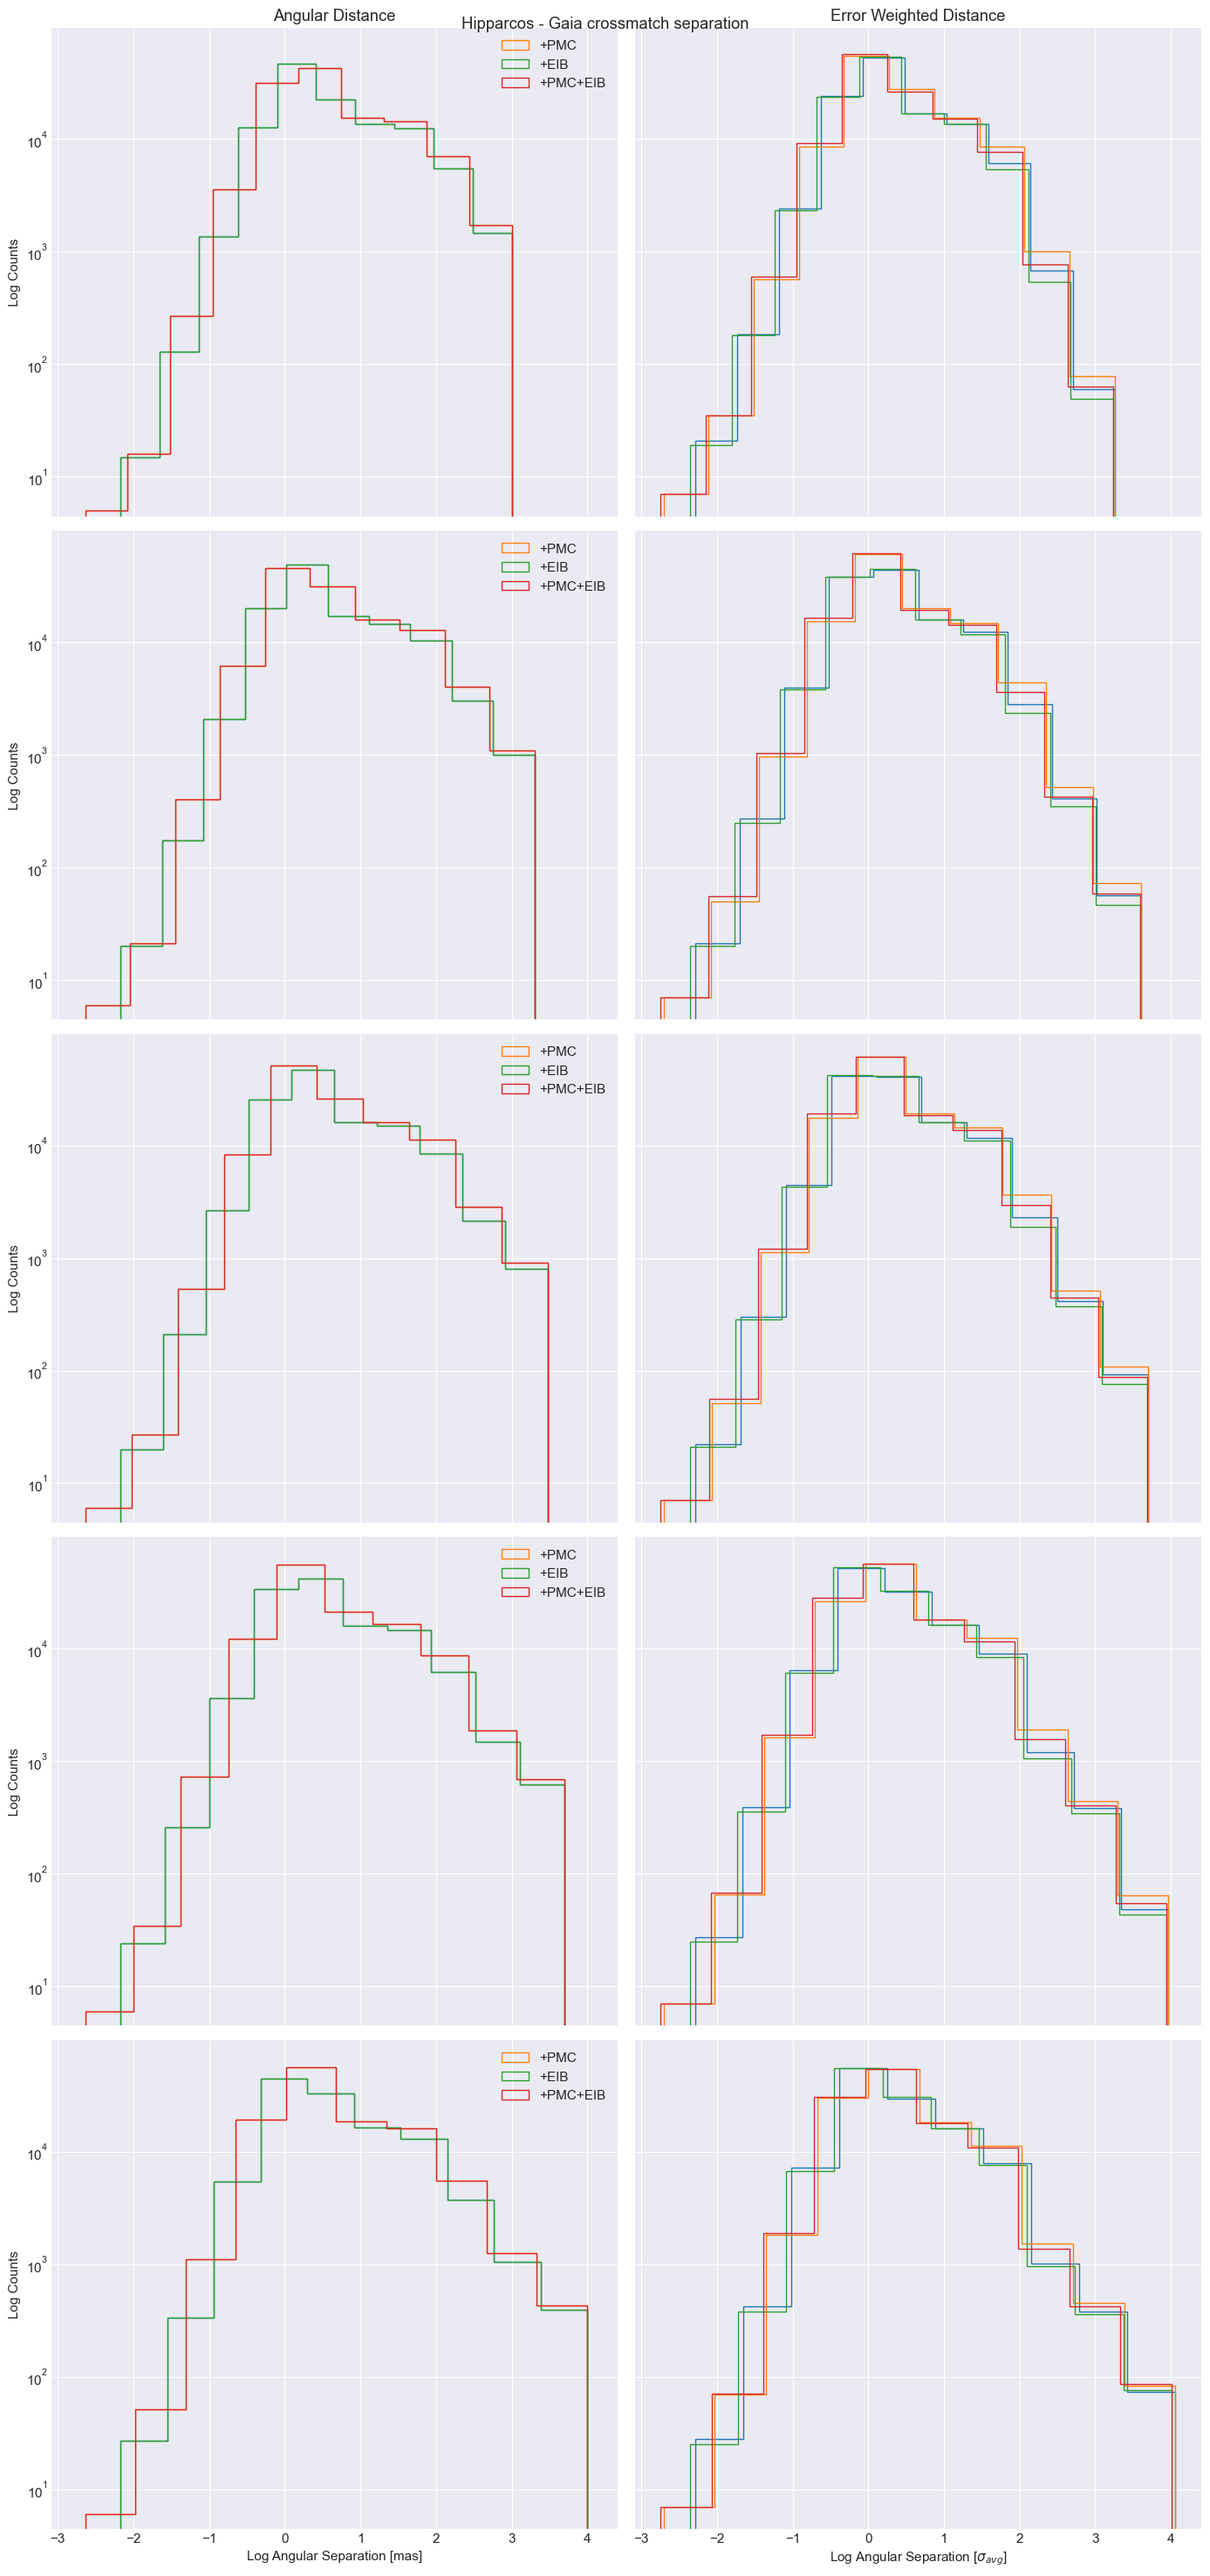

In [112]:
# !TAKE CARE WHEN RUNNING THIS BECAUSE IT WILL MESS WITH THE ABOVE CODE!
extension_types = ['', '+PMC', '+EIB', '+PMC+EIB']
radius = '1as'
method = 'nearest'
radius_ar = ['1as', '2as', '3as', '5as', '10as']

fig, axs = plt.subplots(5,2, figsize=(14,30), sharey=True, sharex=True, tight_layout=True)

# Labelling
axs[4][0].set_xlabel('Log Angular Separation [mas]')
axs[4][1].set_xlabel(r'Log Angular Separation [$\sigma_{avg}$]')

axs[0][0].set_title('Angular Distance')
axs[0][1].set_title('Error Weighted Distance')
plt.suptitle('Hipparcos - Gaia crossmatch separation')



for i, radius in enumerate(radius_ar):
    axs[i][0].set_ylabel('Log Counts')

    for ext in extension_types:
        # Import XM data. xm looks like: [[hip1, source_id1, gaia_cat_id1], [..], ..., [..]]
        xm = np.load(rpath+f'crossmatch{ext}_{radius}_best_neighbour_{method}.npy')

        #Hipp data
        _, pos_hipp_table = query_extra_data(xm, pos_hipp_params, cat='hipp')

        # Create Gaia data table
        cat_gaia = fits.open(f'../../../data/GaiaBaseCat{ext}.fits')[1].data

        # This for loop populates the pos_gaia table following GaiaCat_ID in the xm tables.
        pos_gaia_table = np.zeros((xm.shape[0], len(pos_gaia_params)))
        for j, label in enumerate(pos_gaia_params):
            pos_gaia_table[:, j] = cat_gaia[label][xm[:,2]]

        # Compute distances + Errors
        pos_hipp_table = pos_hipp_table.astype(float)
        pos_gaia_table = pos_gaia_table.astype(float)

        # Annoying work around below. Some error with wrong data types when doing np.radians on everything at the same time.
        # Below code seems to work properly though
        ra_a = np.radians(pos_hipp_table[:,0])
        dec_a = np.radians(pos_hipp_table[:,1])
        ra_b = np.radians(pos_gaia_table[:,0])
        dec_b = np.radians(pos_gaia_table[:,1])
        distances = angular_distance(ra_a, dec_a, ra_b, dec_b)

        distances_mas = np.degrees(distances) * 3600 * 1e3
        avg_hipp_errors = np.sqrt((pos_hipp_table[:, 2])**2 + (pos_hipp_table[:, 3])**2)
        avg_gaia_errors = np.sqrt((pos_gaia_table[:, 2])**1 + (pos_gaia_table[: ,3])**2)
        avg_errors = np.sqrt(avg_hipp_errors**2 + avg_gaia_errors**2)
        error_w_distances = distances_mas / avg_errors

        # Plotting
        axs[i][0].hist(np.log10(distances_mas), log=True, histtype='step', label=ext)#, bins=20)
        axs[i][1].hist(np.log10(error_w_distances), log=True, histtype='step')#, bins=20)



        axs[i][0].legend()
plt.savefig(fpath+f"crossmatch_separation_all", bbox_inches='tight')

## Crossmatch properties numbers table

In [137]:
# !TAKE CARE WHEN RUNNING THIS BECAUSE IT WILL MESS WITH THE ABOVE CODE!
hipp = fits.open(dpath+'Hipparcos2.fits')[1].data
extension_types = ['', '+PMC', '+EIB', '+PMC+EIB']
radius = '1as'
#method = 'nearest'

table = f"Crossmatch Properties Table for {radius}\n"
table += f'Extension & Num. Candidates & Num. Matches & Near-Bright Overlap \\\\ \n'
table += '\hline\n'

for ext in extension_types:
    all = np.load(rpath+f'crossmatch{ext}_{radius}_all_neighbours.npy')
    near = np.load(rpath+f'crossmatch{ext}_{radius}_best_neighbour_nearest.npy')
    bright = np.load(rpath+f'crossmatch{ext}_{radius}_best_neighbour_brightest.npy')

    if (near[:,0] == bright[:,0]).all(): # This should always be true because hip is sorted the same way
        counter = 0
        for i in range(near.shape[0]):
            if near[i][1] == bright[i][1]:
                counter += 1
            #else:
            #    print(f'near:  {near[i][:2]}\nbright: {bright[i][:2]}')
    else:
        raise ValueError("Oops something went wrong with hip ID. Sort arrays?")

    if ext == '':
        ext = '-' # For latex table formatting purposes
    table += f'{ext} & {all.shape[0]} & {near.shape[0]} ({100*near.shape[0]/hipp.shape[0]:.2f} \%) & {counter} ({100*counter/near.shape[0]:.2f} \%) \\\\ \n'
print(table)



Crossmatch Properties Table for 1as
Extension & Num. Candidates & Num. Matches & Near-Bright Overlap \\ 
\hline
- & 117705 & 116901 (99.11 \%) & 116847 (99.95 \%) \\ 
+PMC & 117704 & 116901 (99.11 \%) & 116847 (99.95 \%) \\ 
+EIB & 117705 & 116901 (99.11 \%) & 116847 (99.95 \%) \\ 
+PMC+EIB & 117704 & 116901 (99.11 \%) & 116847 (99.95 \%) \\ 



## Error Normalized Distribution Simulation

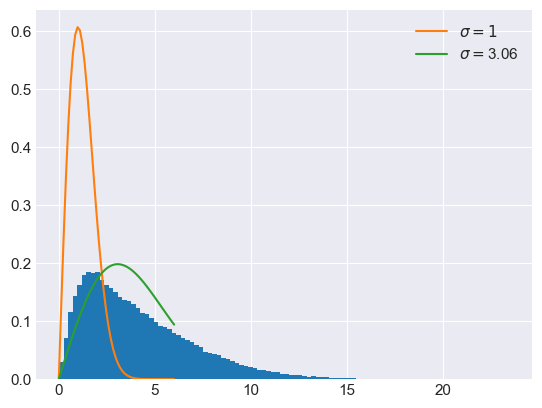

In [6]:
# Most simple case. All Hipparcos and Gaia objects have the same distribution, and the same mean.
num_samples = 100000
error_h = 1
error_g = 5

error_h_ra = error_h
error_h_de = error_h
error_g_ra = error_g
error_g_de = 5*error_g

mean_h = [0,0]
mean_g = [0,0]

hipp_objects = np.random.multivariate_normal(mean_h, [[error_h_ra**2,0],[0,error_h_de**2]], size=num_samples)
gaia_objects = np.random.multivariate_normal(mean_g, [[error_g_ra**2,0],[0,error_g_de**2]], size=num_samples)

norm_h = (1./np.sqrt(2)) * np.sqrt((error_h_ra)**2. + (error_h_de)**2.)
norm_g =  (1./np.sqrt(2)) *  np.sqrt((error_g_ra)**2. + (error_g_de)**2.)
#norm = np.sqrt(norm_h**2 + norm_g**2)
norm = np.sqrt(error_h**2 + error_g**2)
#print(norm_h, norm_g, norm)
distance = np.sqrt((hipp_objects[:,0] - gaia_objects[:,0])**2. + (hipp_objects[:,1] - gaia_objects[:,1])**2.)
distance_norm = distance/norm

#ra_norm = np.sqrt(error_h_ra**2. + error_g_ra**2.)
#de_norm = np.sqrt(error_h_de**2. + error_g_de**2.)
#ra_dist_norm = (hipp_objects[:,0] - gaia_objects[:,0])/ra_norm
#de_dist_norm = (hipp_objects[:,1] - gaia_objects[:,1])/de_norm
#distance_norm = np.sqrt(ra_dist_norm**2 + de_dist_norm**2)

x = np.linspace(0, 6)
n, bins, patches = plt.hist(distance_norm, bins=100, density=True)
bin_middles = np.zeros(n.shape[0])
for i in range(bin_middles.shape[0]):
    bin_middles[i] = bins[i] + 0.5 * (bins[i+1] - bins[i])
popt, pcov = curve_fit(rayleigh, bin_middles, n)


plt.plot(x, rayleigh(x, 1), label=r'$\sigma = 1$')
plt.plot(x, rayleigh(x, popt[0]), label=r'$\sigma = $'+f'{popt[0]:.2f}')
plt.legend()

#plt.xscale('log')

plt.show()

In [15]:
from astrometry_equations import compute_error_normalized_distance
def simulate_dist_norm(means, errors, covariances, EI=1, num_samples=100000):
    """"""
    error_x1 = EI*errors[0][0]
    error_y1 = EI*errors[0][1]
    error_x2 = EI*errors[1][0]
    error_y2 = EI*errors[1][1]

    pos1 = np.random.multivariate_normal(means[0], [[error_x1**2,covariances[0]],[covariances[0],error_y1**2]], size=num_samples)
    pos2 = np.random.multivariate_normal(means[1], [[error_x2**2,covariances[1]],[covariances[1],error_y2**2]], size=num_samples)

    if (errors[:,0] == errors[:,1]).all() and not np.any(covariances):
        distance = np.sqrt((pos1[:,0] - pos2[:,0])**2. + (pos1[:,1] - pos2[:,1])**2.)
        norm = np.sqrt(errors[0][0]**2. + errors[1][0]**2)
        distance_norm = distance/norm

    elif not np.any(covariances) and False:
        distance = np.sqrt((pos1[:,0] - pos2[:,0])**2. + (pos1[:,1] - pos2[:,1])**2.)
        norm1 =  np.sqrt(errors[0][0]**2. + errors[0][1]**2.)
        norm2 =  np.sqrt(errors[1][0]**2. + errors[1][1]**2.)
        norm = np.sqrt(norm1**2. + norm2**2.)
        distance_norm = distance/norm
    else:
        x_norm = np.sqrt(errors[0][0]**2 + errors[1][0]**2)
        y_norm = np.sqrt(errors[0][1]**2 + errors[1][1]**2)
        x_dist_norm = (pos1[:,0] - pos2[:,0])/x_norm
        y_dist_norm = (pos1[:,1] - pos2[:,1])/y_norm
        distance_norm = np.sqrt(x_dist_norm**2. + y_dist_norm**2.)

        unc1 = np.repeat(np.array([error_x1, error_y1, covariances[0]]), num_samples)
        unc1 = np.reshape(unc1, (num_samples, 3))
        unc2 = np.repeat(np.array([error_x2, error_y2, covariances[1]]), num_samples)
        unc2 = np.reshape(unc2, (num_samples, 3))

        print(pos1.shape)
        distance_norm = compute_error_normalized_distance(pos1, pos2, unc1, unc2, method='full')




    return distance_norm

(100000, 2)


LinAlgError: Singular matrix

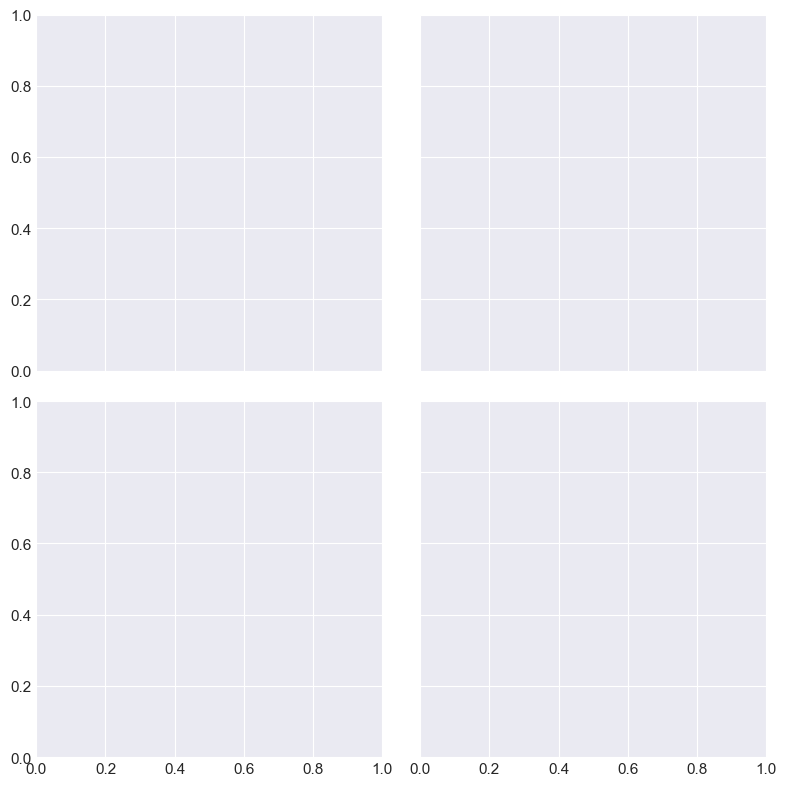

In [22]:
fig, axs = plt.subplots(2,2, figsize=(8,8), tight_layout=True, sharex=True, sharey=True)

means = np.array([[0, 0], [0,0]])
errors = np.array([[1,2], [3,1]])
covariances = np.array([0.01, 0.3])
errors_ar = np.array([[[5,1], [6,1]], [[2,5], [4,3]], [[2,2], [3,1]], [[2, 3], [1, 2]]])

for i in range(len(errors_ar)):
    ax = axs.flatten()[i]
    errors = errors_ar[i]

    distance_norm = simulate_dist_norm(means, errors, covariances, EI=1)
    n, bins, patches = ax.hist(distance_norm, bins=100, density=True, label=r'$\sigma_1 = $'+f'{errors[0]}\n'+r'$\sigma_2 = $'+f'{errors[1]}')
    # Fit Rayleigh Distribution
    x = np.linspace(0, 6)
    bin_middles = np.zeros(n.shape[0])
    for i in range(bin_middles.shape[0]):
        bin_middles[i] = bins[i] + 0.5 * (bins[i+1] - bins[i])
    popt, pcov = curve_fit(rayleigh, bin_middles, n)

    ax.plot(x, rayleigh(x, 1), label='scale = 1')
    ax.plot(x, rayleigh(x, popt[0]), label=f'scale = {popt[0]:.2f}')
    ax.legend()

In [5]:
from plotting_functions import set_styles
from astrometry_equations import rayleigh
set_styles()